In [36]:
# CELL 1 - IMPORTS AND SETTINGS
import os
import glob
import random
import warnings
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_undirected
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import networkx as nx
import seaborn as sns
import re
import requests
from io import StringIO


warnings.filterwarnings("ignore")

RND_SEED = 42
random.seed(RND_SEED)
np.random.seed(RND_SEED)
torch.manual_seed(RND_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CHANGE THIS TO YOUR REAL LOCAL DATA PATH
DATA_FOLDER = r"/Users/test/Documents/Covid/Covid 19 different timeline"
ADJ_FILE = "https://www2.census.gov/geo/docs/reference/county_adjacency.txt"

TARGET_COL = "casesper100klast7days"
LOOKBACK_LAGS = [1, 2, 3, 7]
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

HIDDEN_DIM = 64
GCN_HIDDEN = 32
DROPOUT = 0.15
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 60
PATIENCE = 10

OUT_DIR = os.path.join(DATA_FOLDER, "gnn_outputs_fixed")
os.makedirs(OUT_DIR, exist_ok=True)

print("DEVICE:", DEVICE)
print("DATA_FOLDER exists:", os.path.exists(DATA_FOLDER))
print("OUT_DIR:", OUT_DIR)

DEVICE: cpu
DATA_FOLDER exists: True
OUT_DIR: /Users/test/Documents/Covid/Covid 19 different timeline/gnn_outputs_fixed


In [37]:
# CELL 2 - HELPERS, FIPS CLEANING, PANEL LOAD

def normalize_col_name(c):
    c = str(c).strip().lower()
    c = c.replace("%", "pct")
    c = c.replace("-", "_").replace(" ", "_").replace("/", "_")
    while "__" in c:
        c = c.replace("__", "_")
    return c.strip("_")


def clean_fips(x):
    if pd.isna(x):
        return np.nan
    s = "".join(ch for ch in str(x) if ch.isdigit())
    if s == "":
        return np.nan
    return s.zfill(5)[-5:]


def load_all_csvs(data_folder):
    files = sorted(glob.glob(os.path.join(data_folder, "*.csv")))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {data_folder}")

    rename_map = {
        "cases_per_100k_last_7_days": "casesper100klast7days",
        "cases_last_7_days": "caseslast7days",
        "total_cases": "totalcases",
        "deaths_last_7_days": "deathslast7days",
        "deaths_per_100k_last_7_days": "deathsper100klast7days",
        "total_deaths": "totaldeaths",
        "test_positivity_rate_last_7_days": "testpositivityratelast7days",
        "confirmed_covid_hosp_last_7_days": "confirmedcovidhosplast7days",
        "confirmed_covid_hosp_per_100_beds_last_7_days": "confirmedcovidhospper100bedslast7days",
        "suspected_covid_hosp_last_7_days": "suspectedcovidhosplast7days",
        "suspected_covid_hosp_per_100_beds_last_7_days": "suspectedcovidhospper100bedslast7days",
        "pct_inpatient_beds_used_avg_last_7_days": "pctinpatientbedsusedavglast7days",
        "pct_inpatient_beds_used_covid_avg_last_7_days": "pctinpatientbedsusedcovidavglast7days",
        "pct_icu_beds_used_avg_last_7_days": "pcticubedsusedavglast7days",
        "pct_icu_beds_used_covid_avg_last_7_days": "pcticubedsusedcovidavglast7days",
    }

    dfs = []
    for fp in files:
        df = pd.read_csv(fp, dtype={"fips": str}, low_memory=False)
        df.columns = [normalize_col_name(c) for c in df.columns]
        df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

        if "fips" not in df.columns:
            continue

        df["fips"] = df["fips"].apply(clean_fips)
        df = df[df["fips"].notna()].copy()

        if "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
        else:
            stem = os.path.basename(fp).replace(".csv", "")
            stem = stem.replace("_", "-")
            df["date"] = pd.to_datetime(stem, errors="coerce")

        if "county" not in df.columns:
            df["county"] = None
        if "state" not in df.columns:
            df["state"] = None

        df["source_file"] = os.path.basename(fp)
        dfs.append(df)

    panel = pd.concat(dfs, ignore_index=True)
    panel = panel[panel["date"].notna()].copy()
    panel["state"] = panel["state"].astype(str).str.upper().str.strip()
    panel["county"] = panel["county"].astype(str).str.strip()
    panel["statefips"] = panel["fips"].str[:2]
    panel = panel[~panel["county"].str.contains("unallocated", case=False, na=False)].copy()
    panel = (
        panel.sort_values(["date", "fips"])
        .drop_duplicates(subset=["date", "fips"], keep="last")
        .reset_index(drop=True)
    )
    return panel


panel = load_all_csvs(DATA_FOLDER)
print("panel shape:", panel.shape)
print("date range:", panel["date"].min(), "to", panel["date"].max())
print(panel[["fips", "county", "state", "date"]].head())

panel shape: (668472, 41)
date range: 2021-02-22 00:00:00 to 2023-05-10 00:00:00
    fips              county state       date
0  01001  Autauga County, AL    AL 2021-02-22
1  01003  Baldwin County, AL    AL 2021-02-22
2  01005  Barbour County, AL    AL 2021-02-22
3  01007     Bibb County, AL    AL 2021-02-22
4  01009   Blount County, AL    AL 2021-02-22


In [38]:
# CELL 3 - ROBUST COUNTY NEIGHBOR ADJACENCY LOADER



def load_census_adjacency(adj_file):
    resp = requests.get(adj_file, timeout=60)
    resp.raise_for_status()
    raw = resp.content

    text = None
    for enc in ["utf-8", "latin1", "cp1252"]:
        try:
            text = raw.decode(enc)
            print(f"Adjacency file decoded with: {enc}")
            break
        except UnicodeDecodeError:
            continue

    if text is None:
        raise ValueError("Could not decode adjacency file with utf-8, latin1, or cp1252")

    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    pairs = []

    for ln in lines:
        fips_found = re.findall(r"\b\d{5}\b", ln)
        if len(fips_found) >= 2:
            base = clean_fips(fips_found[0])
            for nb in fips_found[1:]:
                nb = clean_fips(nb)
                if pd.notna(base) and pd.notna(nb) and base != nb:
                    u, v = sorted([base, nb])
                    pairs.append((u, v))

    if not pairs:
        raise ValueError("No county adjacency pairs were extracted from the census file")

    adj = pd.DataFrame(pairs, columns=["fips", "neighborfips"]).drop_duplicates().reset_index(drop=True)
    return adj

adj_pairs = load_census_adjacency(ADJ_FILE)

county_lookup = (
    panel.sort_values("date")
    .drop_duplicates("fips")[["fips", "county", "state", "statefips"]]
    .copy()
)

valid_fips = set(county_lookup["fips"])
adj_pairs = adj_pairs[
    adj_pairs["fips"].isin(valid_fips) & adj_pairs["neighborfips"].isin(valid_fips)
].copy()

state_map = county_lookup.set_index("fips")["state"].to_dict()
adj_pairs["state"] = adj_pairs["fips"].map(state_map)
adj_pairs["neighbor_state"] = adj_pairs["neighborfips"].map(state_map)

intrastate_edges_df = adj_pairs[
    adj_pairs["state"] == adj_pairs["neighbor_state"]
][["fips", "neighborfips"]].copy()

interstate_edges_df = adj_pairs[
    adj_pairs["state"] != adj_pairs["neighbor_state"]
][["fips", "neighborfips"]].copy()

print("all clean edges:", len(adj_pairs))
print("intra-state edges:", len(intrastate_edges_df))
print("inter-state edges:", len(interstate_edges_df))
print(adj_pairs.head())

Adjacency file decoded with: latin1
all clean edges: 2794
intra-state edges: 2157
inter-state edges: 637
    fips neighborfips state neighbor_state
0  01005        01011    AL             AL
1  01015        01019    AL             AL
2  01001        01021    AL             AL
3  01003        01025    AL             AL
4  01015        01029    AL             AL


In [39]:
# CELL 4 - LEAKAGE-SAFE FEATURE BUILD, NEXT-STEP TARGET

candidate_features = [
    "caseslast7days",
    "casesper100klast7days",
    "totalcases",
    "deathslast7days",
    "deathsper100klast7days",
    "totaldeaths",
    "testpositivityratelast7days",
    "confirmedcovidhosplast7days",
    "confirmedcovidhospper100bedslast7days",
    "suspectedcovidhosplast7days",
    "suspectedcovidhospper100bedslast7days",
    "pctinpatientbedsusedavglast7days",
    "pctinpatientbedsusedcovidavglast7days",
    "pcticubedsusedavglast7days",
    "pcticubedsusedcovidavglast7days",
]

feature_cols = [c for c in candidate_features if c in panel.columns]
panel = panel.sort_values(["fips", "date"]).copy()

lag_feature_cols = []
for c in feature_cols:
    panel[c] = pd.to_numeric(panel[c], errors="coerce")
    lag1 = f"{c}_lag1"
    panel[lag1] = panel.groupby("fips")[c].shift(1)
    lag_feature_cols.append(lag1)

for lag in LOOKBACK_LAGS:
    col = f"{TARGET_COL}_lag{lag}"
    panel[col] = panel.groupby("fips")[TARGET_COL].shift(lag)
    lag_feature_cols.append(col)

lag_feature_cols = sorted(set(lag_feature_cols))

panel["target_t_plus_1_raw"] = panel.groupby("fips")[TARGET_COL].shift(-1)
panel["target_t_plus_1_raw"] = pd.to_numeric(
    panel["target_t_plus_1_raw"], errors="coerce"
).clip(lower=0)

# Fix 1
panel["target_t_plus_1"] = np.log1p(panel["target_t_plus_1_raw"])

model_df = panel.dropna(subset=["target_t_plus_1"]).copy()
for c in lag_feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

print("model_df shape:", model_df.shape)
print("n lag features:", len(lag_feature_cols))
print(model_df[["fips", "date", "target_t_plus_1_raw", "target_t_plus_1"]].head())

model_df shape: (663334, 61)
n lag features: 18
        fips       date  target_t_plus_1_raw  target_t_plus_1
0      01001 2021-02-22              187.940         5.241430
3220   01001 2021-02-23              218.368         5.390751
6440   01001 2021-02-24              236.267         5.469186
9660   01001 2021-02-25              279.225         5.635593
12880  01001 2021-02-27              266.695         5.589848


In [40]:
# CELL 5 - TEMPORAL SPLIT + TRAIN-ONLY SCALER

all_dates = sorted(model_df["date"].dropna().unique())
n_dates = len(all_dates)

train_end = int(n_dates * TRAIN_RATIO)
val_end = int(n_dates * (TRAIN_RATIO + VAL_RATIO))

train_dates = all_dates[:train_end]
val_dates = all_dates[train_end:val_end]
test_dates = all_dates[val_end:]

train_df = model_df[model_df["date"].isin(train_dates)].copy()
val_df = model_df[model_df["date"].isin(val_dates)].copy()
test_df = model_df[model_df["date"].isin(test_dates)].copy()

# Fix 4
train_means = train_df[lag_feature_cols].mean(numeric_only=True)
train_stds = train_df[lag_feature_cols].std(numeric_only=True).replace(0, 1).fillna(1)

def apply_train_scaler(df, cols, means, stds):
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
        out[c] = ((out[c] - means[c]) / stds[c]).fillna(0.0)
    return out

train_df = apply_train_scaler(train_df, lag_feature_cols, train_means, train_stds)
val_df = apply_train_scaler(val_df, lag_feature_cols, train_means, train_stds)
test_df = apply_train_scaler(test_df, lag_feature_cols, train_means, train_stds)

print("Train dates:", len(train_dates), "Val dates:", len(val_dates), "Test dates:", len(test_dates))
print(train_df.shape, val_df.shape, test_df.shape)

Train dates: 144 Val dates: 31 Test dates: 31
(463680, 61) (99820, 61) (99834, 61)


In [41]:
# CELL 6 - NODE INDEX AND EDGE INDEX

all_counties = sorted(model_df["fips"].unique())
county_to_idx = {f: i for i, f in enumerate(all_counties)}
idx_to_county = {i: f for f, i in county_to_idx.items()}
n_nodes = len(all_counties)

def make_edge_index(edge_df, county_to_idx):
    tmp = edge_df.copy()
    tmp = tmp[tmp["fips"].isin(county_to_idx) & tmp["neighborfips"].isin(county_to_idx)].copy()
    src = tmp["fips"].map(county_to_idx).astype(int).values
    dst = tmp["neighborfips"].map(county_to_idx).astype(int).values
    edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
    return to_undirected(edge_index)

edge_index_intra = make_edge_index(intrastate_edges_df, county_to_idx).to(DEVICE)
edge_index_inter = make_edge_index(interstate_edges_df, county_to_idx).to(DEVICE)

print("n_nodes:", n_nodes)
print("edge_index_intra:", edge_index_intra.shape)
print("edge_index_inter:", edge_index_inter.shape)

n_nodes: 3221
edge_index_intra: torch.Size([2, 4308])
edge_index_inter: torch.Size([2, 1274])


In [42]:
# CELL 7 - SNAPSHOT BUILDER

county_state_lookup = county_lookup.set_index("fips")["state"].to_dict()

def build_snapshot(df_day):
    x = np.zeros((n_nodes, len(lag_feature_cols)), dtype=np.float32)
    y_log = np.full((n_nodes,), np.nan, dtype=np.float32)
    y_raw = np.full((n_nodes,), np.nan, dtype=np.float32)
    mask = np.zeros((n_nodes,), dtype=bool)
    active = np.zeros((n_nodes,), dtype=np.float32)

    for _, row in df_day.iterrows():
        fips = row["fips"]
        if fips not in county_to_idx:
            continue
        idx = county_to_idx[fips]
        x[idx, :] = row[lag_feature_cols].values.astype(np.float32)
        y_log[idx] = np.float32(row["target_t_plus_1"])
        y_raw[idx] = np.float32(row["target_t_plus_1_raw"])
        mask[idx] = True
        active[idx] = 1.0

    return {
        "x": torch.tensor(x, dtype=torch.float32, device=DEVICE),
        "y_log": torch.tensor(y_log, dtype=torch.float32, device=DEVICE),
        "y_raw": torch.tensor(y_raw, dtype=torch.float32, device=DEVICE),
        "mask": torch.tensor(mask, dtype=torch.bool, device=DEVICE),
        "active": torch.tensor(active, dtype=torch.float32, device=DEVICE).unsqueeze(-1),
    }

train_snaps = {d: build_snapshot(train_df[train_df["date"] == d]) for d in train_dates}
val_snaps = {d: build_snapshot(val_df[val_df["date"] == d]) for d in val_dates}
test_snaps = {d: build_snapshot(test_df[test_df["date"] == d]) for d in test_dates}

print("snapshots ready:", len(train_snaps), len(val_snaps), len(test_snaps))

snapshots ready: 144 31 31


In [43]:
# CELL 8 - FIXED MODEL

class FixedThreePartSTGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, gcn_hidden, dropout=0.15):
        super().__init__()
        self.self_linear = nn.Linear(in_dim, hidden_dim)
        self.gcn_intra = GCNConv(in_dim, gcn_hidden)
        self.gcn_inter = GCNConv(in_dim, gcn_hidden)
        self.neigh_linear = nn.Linear(2 * gcn_hidden, hidden_dim)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
        self.fuse = nn.Linear(hidden_dim * 3, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.alpha_self = nn.Parameter(torch.tensor(0.55))
        self.alpha_neigh = nn.Parameter(torch.tensor(0.25))
        self.alpha_mem = nn.Parameter(torch.tensor(0.20))

    def forward_step(self, x_t, h_prev, active_t, edge_intra, edge_inter):
        x_eff = x_t * active_t

        self_part = torch.relu(self.self_linear(x_eff))
        intra_part = torch.relu(self.gcn_intra(x_eff, edge_intra))
        inter_part = torch.relu(self.gcn_inter(x_eff, edge_inter))
        neigh_part = torch.relu(self.neigh_linear(torch.cat([intra_part, inter_part], dim=-1)))
        mem_part = self.gru(self_part + 0.5 * neigh_part, h_prev)

        a = torch.softmax(torch.stack([self.alpha_self, self.alpha_neigh, self.alpha_mem]), dim=0)
        fused = torch.cat([a[0] * self_part, a[1] * neigh_part, a[2] * mem_part], dim=-1)
        h_t = torch.relu(self.fuse(fused))
        h_t = self.dropout(h_t)

        # Fix 2: output in log-space
        y_hat_log = self.out(h_t).squeeze(-1)
        return y_hat_log, h_t


model = FixedThreePartSTGNN(
    in_dim=len(lag_feature_cols),
    hidden_dim=HIDDEN_DIM,
    gcn_hidden=GCN_HIDDEN,
    dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
print(model)

FixedThreePartSTGNN(
  (self_linear): Linear(in_features=18, out_features=64, bias=True)
  (gcn_intra): GCNConv(18, 32)
  (gcn_inter): GCNConv(18, 32)
  (neigh_linear): Linear(in_features=64, out_features=64, bias=True)
  (gru): GRUCell(64, 64)
  (fuse): Linear(in_features=192, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.15, inplace=False)
)


In [44]:
# CELL 9 - UNIFIED TRAIN / EVAL PIPELINE

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_snapshots(model, snapshots, edge_intra, edge_inter, split_name="split"):
    model.eval()
    preds_raw_all, trues_raw_all, rows = [], [], []
    h_prev = torch.zeros((n_nodes, HIDDEN_DIM), device=DEVICE)

    with torch.no_grad():
        for d in sorted(snapshots.keys()):
            snap = snapshots[d]
            y_hat_log, h_prev = model.forward_step(
                snap["x"], h_prev, snap["active"], edge_intra, edge_inter
            )

            # Fix 2 + Fix 5
            y_pred_raw = torch.expm1(y_hat_log).clamp(min=0)

            mask = snap["mask"]
            y_true_raw = snap["y_raw"][mask].detach().cpu().numpy()
            y_pred_raw_np = y_pred_raw[mask].detach().cpu().numpy()
            node_indices = torch.where(mask)[0].detach().cpu().numpy()

            preds_raw_all.extend(y_pred_raw_np.tolist())
            trues_raw_all.extend(y_true_raw.tolist())

            for idx, yt, yp in zip(node_indices, y_true_raw, y_pred_raw_np):
                fips = idx_to_county[int(idx)]
                rows.append(
                    {
                        "date": pd.Timestamp(d),
                        "fips": fips,
                        "state": county_state_lookup.get(fips, None),
                        "ytrue": float(yt),
                        "ypred": float(max(0.0, yp)),
                    }
                )

    detail = pd.DataFrame(rows).sort_values(["date", "state", "fips"]).reset_index(drop=True)
    metrics = {
        "split": split_name,
        "rmse": rmse(trues_raw_all, preds_raw_all),
        "mae": float(mean_absolute_error(trues_raw_all, preds_raw_all)),
        "detail": detail,
        "n_rows": len(detail),
        "n_unique_pred_values_rounded_2dp": int(detail["ypred"].round(2).nunique()) if len(detail) else 0,
    }
    return metrics


def train_model(model, train_snaps, val_snaps, edge_intra, edge_inter):
    best_val = np.inf
    best_state = None
    patience_left = PATIENCE

    for epoch in range(1, EPOCHS + 1):
        model.train()
        h_prev = torch.zeros((n_nodes, HIDDEN_DIM), device=DEVICE)
        losses = []

        for d in sorted(train_snaps.keys()):
            snap = train_snaps[d]
            optimizer.zero_grad()
            y_hat_log, h_prev = model.forward_step(
                snap["x"], h_prev, snap["active"], edge_intra, edge_inter
            )
            loss = F.huber_loss(y_hat_log[snap["mask"]], snap["y_log"][snap["mask"]], delta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            h_prev = h_prev.detach()
            losses.append(loss.item())

        val_metrics = evaluate_snapshots(model, val_snaps, edge_intra, edge_inter, split_name="VAL")
        print(
            f"Epoch {epoch:03d} TrainLoss {np.mean(losses):.4f} "
            f"ValRMSE {val_metrics['rmse']:.4f} ValMAE {val_metrics['mae']:.4f}"
        )

        if val_metrics["rmse"] < best_val:
            best_val = val_metrics["rmse"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    return model


model = train_model(model, train_snaps, val_snaps, edge_index_intra, edge_index_inter)

Epoch 001 TrainLoss 1.9849 ValRMSE 299.8630 ValMAE 152.8739
Epoch 002 TrainLoss 1.3280 ValRMSE 259.2140 ValMAE 157.0937
Epoch 003 TrainLoss 1.1274 ValRMSE 262.2554 ValMAE 161.0588
Epoch 004 TrainLoss 1.1185 ValRMSE 253.6811 ValMAE 151.4026
Epoch 005 TrainLoss 0.9803 ValRMSE 252.3188 ValMAE 149.9187
Epoch 006 TrainLoss 1.0049 ValRMSE 253.1400 ValMAE 151.1223
Epoch 007 TrainLoss 0.8190 ValRMSE 245.3110 ValMAE 141.9717
Epoch 008 TrainLoss 0.9047 ValRMSE 253.4105 ValMAE 135.5794
Epoch 009 TrainLoss 0.8727 ValRMSE 477.4726 ValMAE 132.4962
Epoch 010 TrainLoss 0.8015 ValRMSE 234.4094 ValMAE 127.5328
Epoch 011 TrainLoss 0.7370 ValRMSE 230.7679 ValMAE 124.8461
Epoch 012 TrainLoss 0.8016 ValRMSE 246.3255 ValMAE 127.1092
Epoch 013 TrainLoss 0.8059 ValRMSE 266.9662 ValMAE 126.8952
Epoch 014 TrainLoss 0.7856 ValRMSE 266.3521 ValMAE 125.6615
Epoch 015 TrainLoss 0.7668 ValRMSE 242.6404 ValMAE 131.5883
Epoch 016 TrainLoss 0.7343 ValRMSE 230.2772 ValMAE 124.6166
Epoch 017 TrainLoss 0.7340 ValRMSE 236.7

In [45]:
# CELL 10 - FULL EVALUATION + COLLAPSE CHECKS

train_metrics = evaluate_snapshots(model, train_snaps, edge_index_intra, edge_index_inter, split_name="TRAIN")
val_metrics = evaluate_snapshots(model, val_snaps, edge_index_intra, edge_index_inter, split_name="VAL")
test_metrics = evaluate_snapshots(model, test_snaps, edge_index_intra, edge_index_inter, split_name="TEST")

for m in [train_metrics, val_metrics, test_metrics]:
    print(
        m["split"],
        "RMSE=", round(m["rmse"], 4),
        "MAE=", round(m["mae"], 4),
        "Rows=", m["n_rows"],
        "RoundedUniquePred=", m["n_unique_pred_values_rounded_2dp"],
    )

county_results = test_metrics["detail"].copy()
print(county_results.head())
print("Negative preds present:", bool((county_results["ypred"] < 0).any()))

TRAIN RMSE= 3774.3724 MAE= 1555.3951 Rows= 463680 RoundedUniquePred= 59543
VAL RMSE= 230.2772 MAE= 124.6166 Rows= 99820 RoundedUniquePred= 13413
TEST RMSE= 101.6539 MAE= 52.7851 Rows= 99834 RoundedUniquePred= 10650
        date   fips state       ytrue      ypred
0 2022-08-31  02013    AK   29.966999  15.844171
1 2022-08-31  02016    AK    0.000000   7.176428
2 2022-08-31  02020    AK  135.417007  10.852219
3 2022-08-31  02050    AK  598.281006  12.076902
4 2022-08-31  02060    AK    0.000000   5.119051
Negative preds present: False


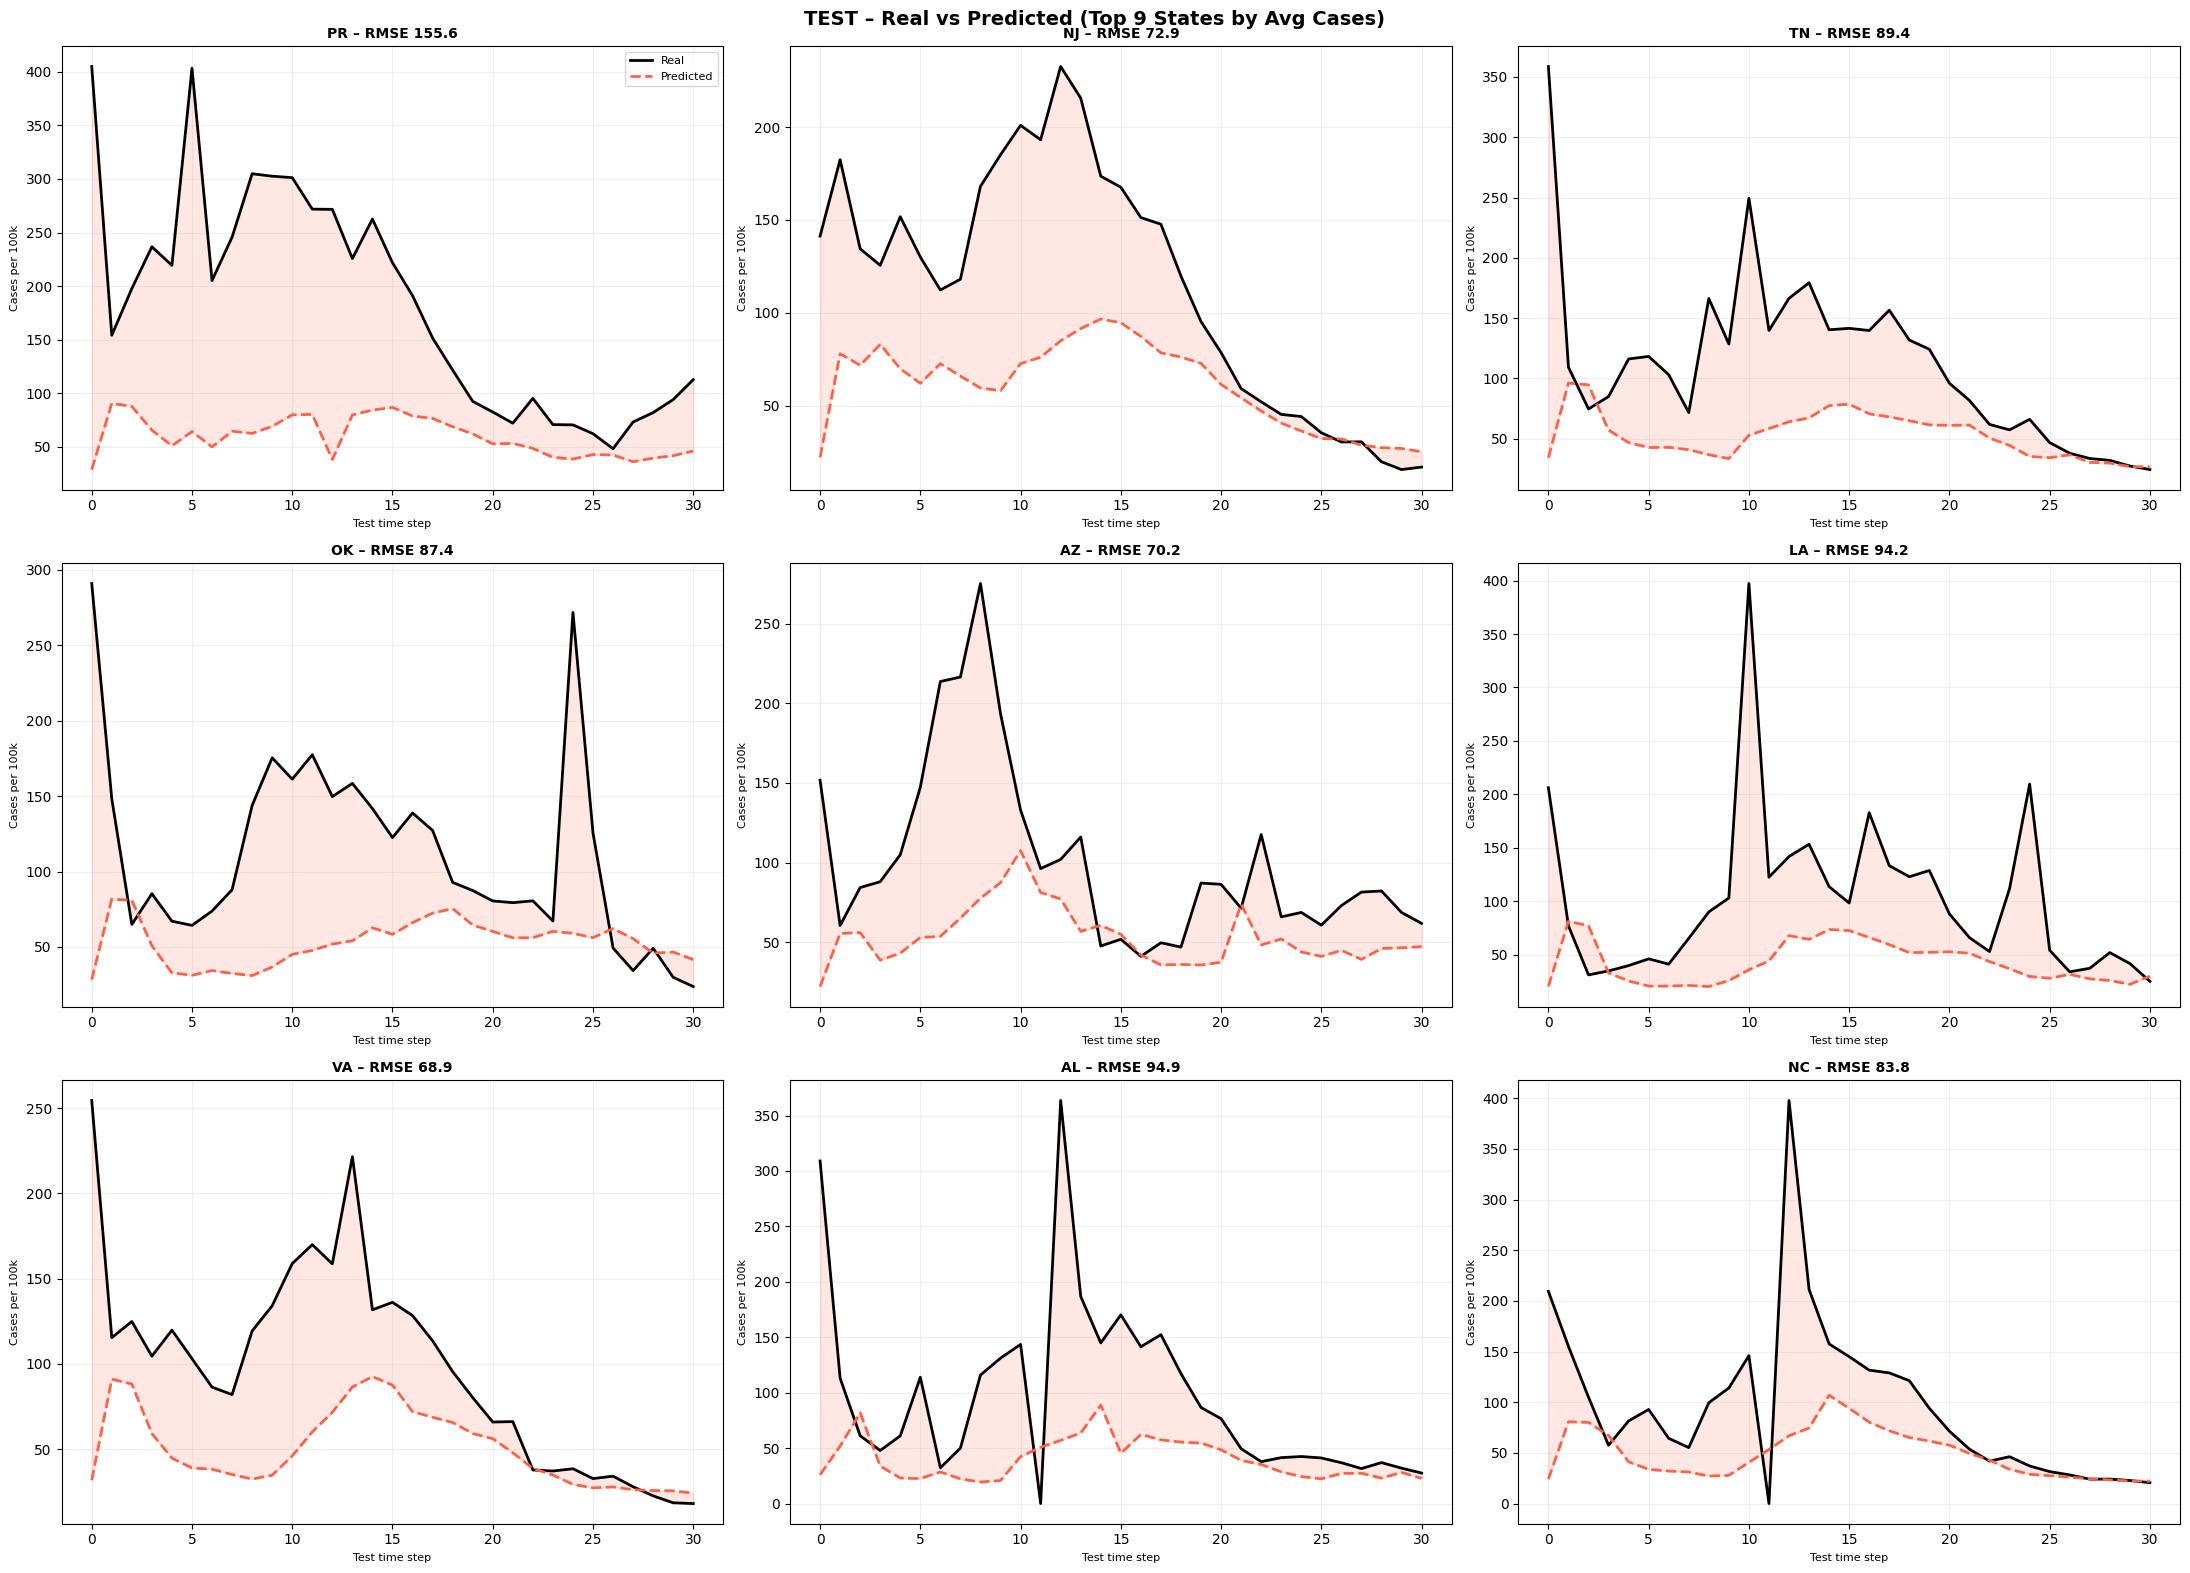

Plot 2 (testrealvspredtop9) created.


In [46]:
# CELL 15 – test period, real vs predicted for top 9 states


test_state_mean = (
    test_metrics["detail"]
    .groupby("state", as_index=False)["ytrue"].mean()
    .sort_values("ytrue", ascending=False)
)

top9_states = test_state_mean.head(9)["state"].tolist()

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
axes = axes.flatten()

for i, st in enumerate(top9_states):
    stdf = (
        test_metrics["detail"]
        [test_metrics["detail"]["state"] == st]
        .groupby("date", as_index=False)
        .agg(ytrue=("ytrue", "mean"), ypred=("ypred", "mean"))
        .sort_values("date")
    )
    x = range(len(stdf))
    ax = axes[i]
    ax.plot(x, stdf["ytrue"].values, color="black", linewidth=2, label="Real")
    ax.plot(x, stdf["ypred"].values, color="tomato", linestyle="--", linewidth=2, label="Predicted")
    ax.fill_between(
        x,
        stdf["ytrue"].values,
        stdf["ypred"].values,
        color="tomato",
        alpha=0.15,
    )
    rmse_st = np.sqrt(mean_squared_error(stdf["ytrue"], stdf["ypred"]))
    ax.set_title(f"{st} – RMSE {rmse_st:.1f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Test time step", fontsize=8)
    ax.set_ylabel("Cases per 100k", fontsize=8)
    ax.grid(alpha=0.2)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

for j in range(len(top9_states), len(axes)):
    axes[j].axis("off")

plt.suptitle("TEST – Real vs Predicted (Top 9 States by Avg Cases)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("Plot 2 (testrealvspredtop9) created.")

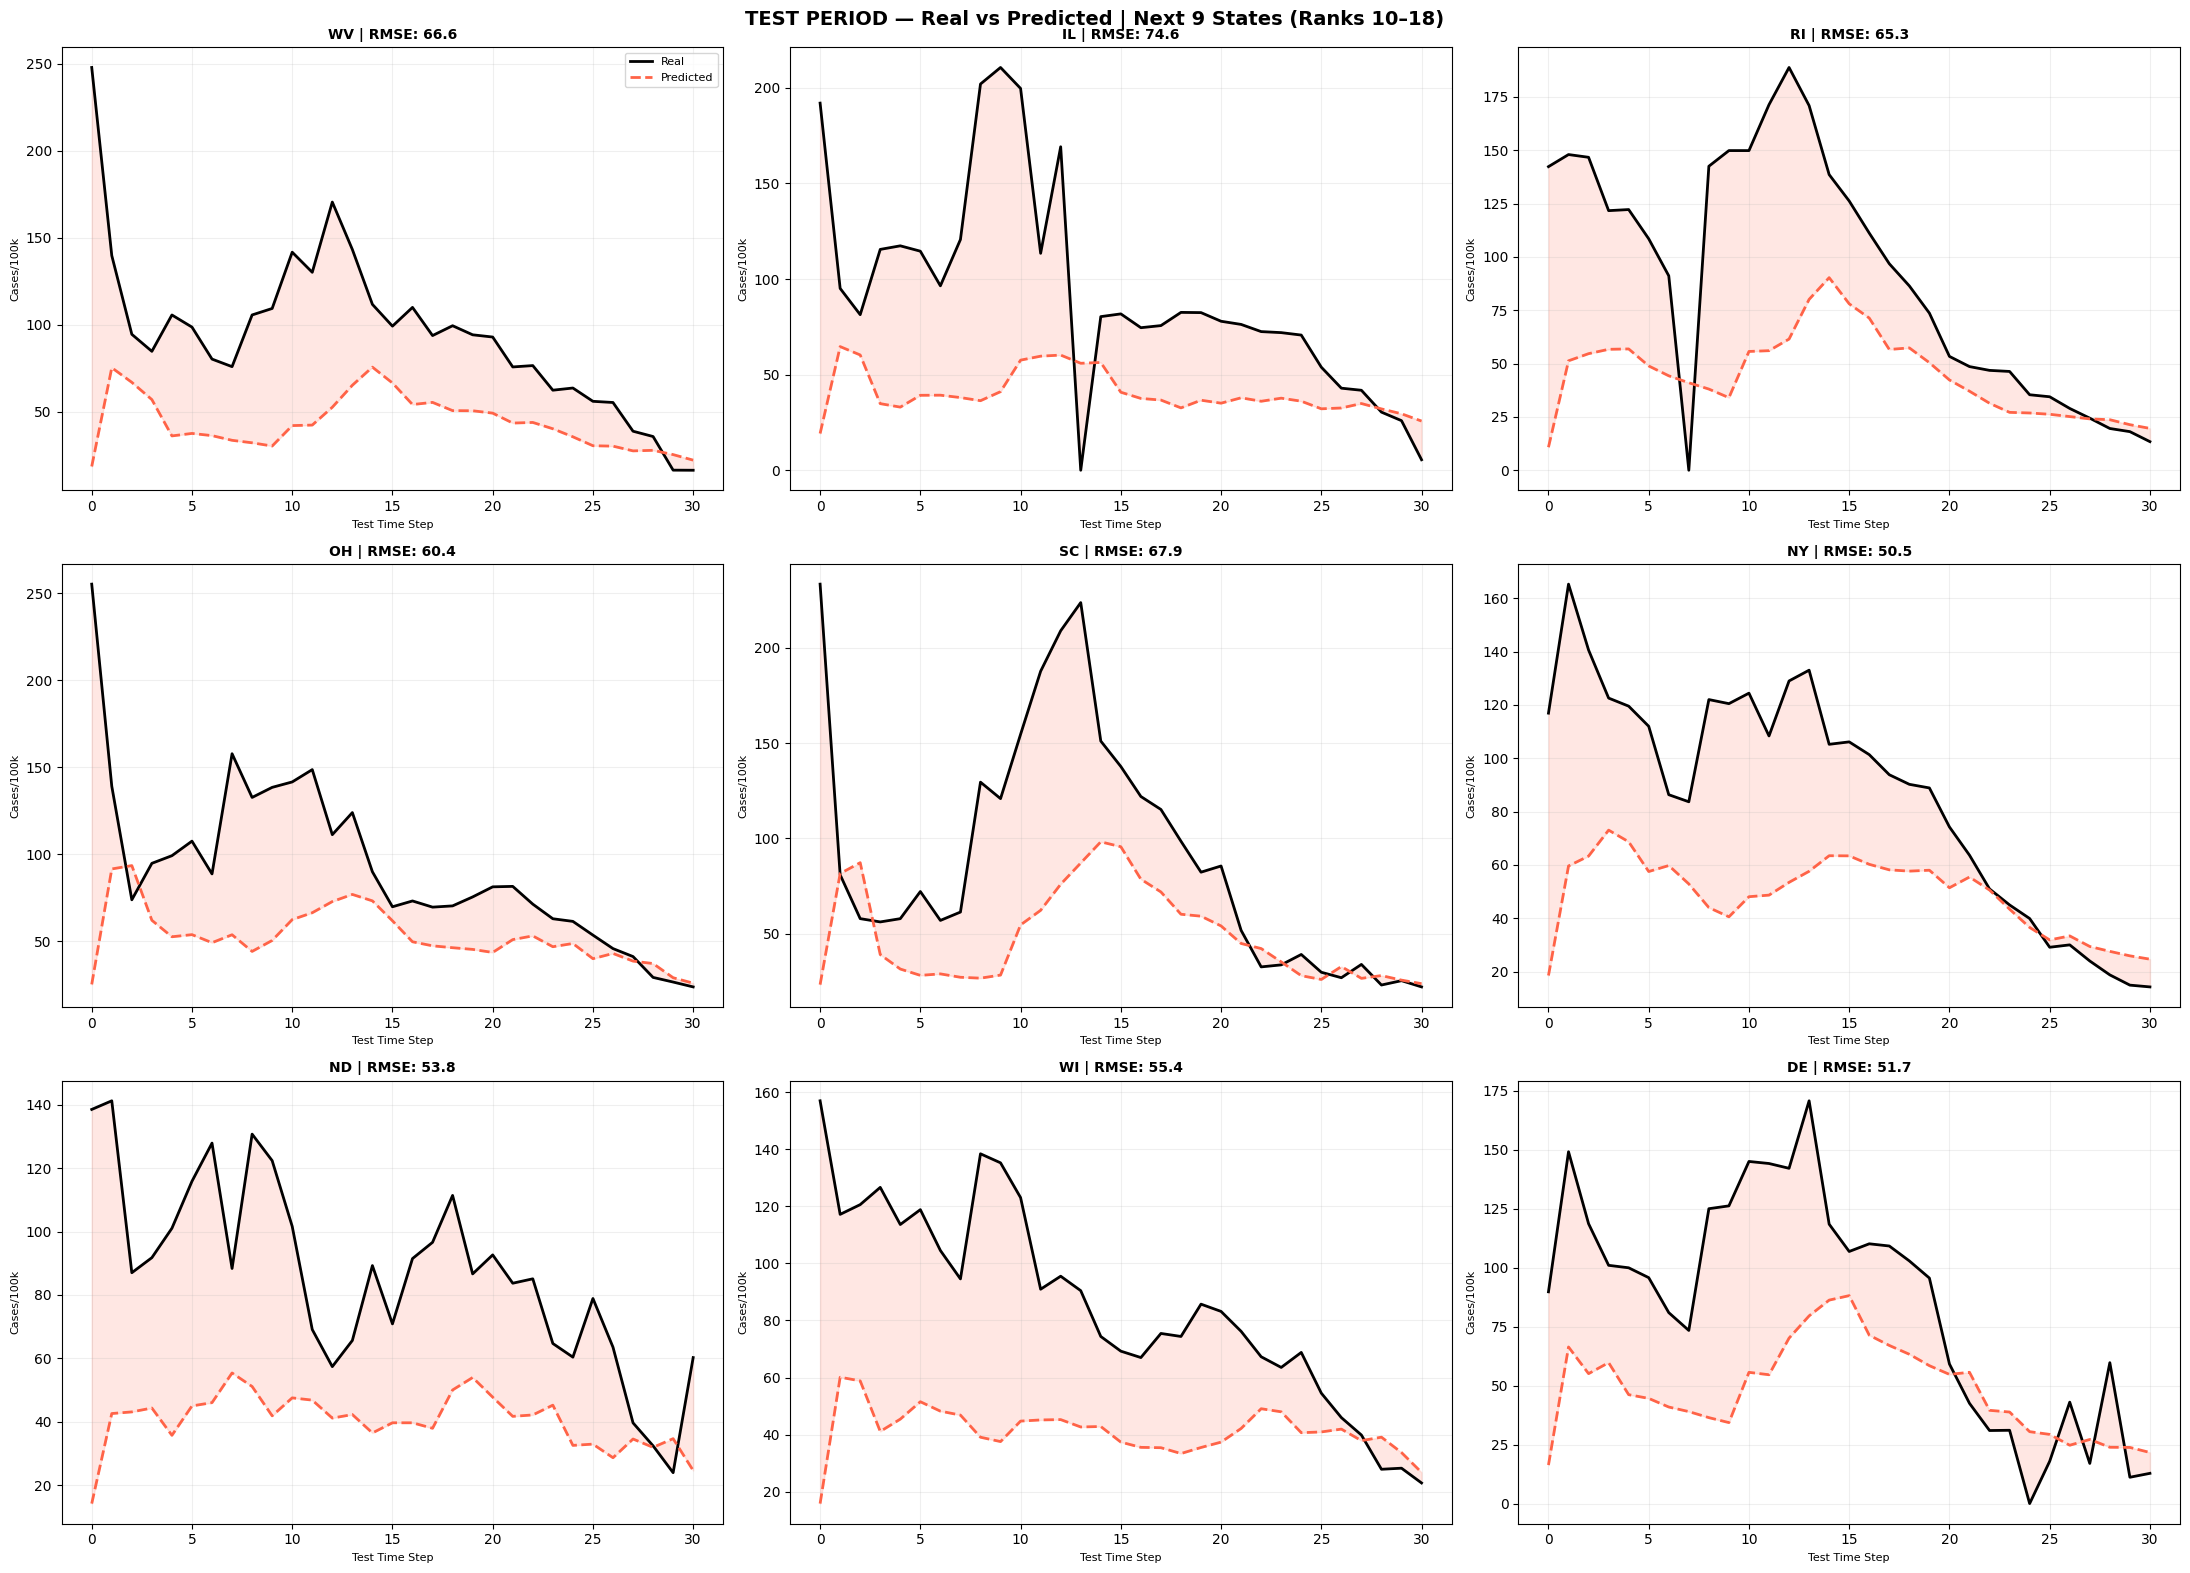

Next-9 test plot created.


In [47]:
# CELL – TEST period, real vs predicted for NEXT 9 states (ranks 10–18)


# reuse test_state_mean from the previous cell, or recompute if not in scope:
# test_state_mean = (
#     test_metrics["detail"]
#     .groupby("state", as_index=False)["ytrue"].mean()
#     .sort_values("ytrue", ascending=False)
# )

next9_states = test_state_mean.iloc[9:18]["state"].tolist()  # ranks 10–18

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
axes = axes.flatten()

for i, st in enumerate(next9_states):
    stdf = (
        test_metrics["detail"]
        [test_metrics["detail"]["state"] == st]
        .groupby("date", as_index=False)
        .agg(ytrue=("ytrue", "mean"), ypred=("ypred", "mean"))
        .sort_values("date")
    )

    x = range(len(stdf))
    ax = axes[i]

    ax.plot(x, stdf["ytrue"].values, color="black", linewidth=2, label="Real")
    ax.plot(
        x,
        stdf["ypred"].values,
        color="tomato",
        linestyle="--",
        linewidth=2,
        label="Predicted",
    )
    ax.fill_between(
        x,
        stdf["ytrue"].values,
        stdf["ypred"].values,
        color="tomato",
        alpha=0.15,
    )

    rmse_st = np.sqrt(mean_squared_error(stdf["ytrue"], stdf["ypred"]))
    ax.set_title(f"{st} | RMSE: {rmse_st:.1f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Test Time Step", fontsize=8)
    ax.set_ylabel("Cases/100k", fontsize=8)
    ax.grid(alpha=0.2)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

# turn off any unused axes (in case fewer than 9 states)
for j in range(len(next9_states), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "TEST PERIOD — Real vs Predicted | Next 9 States (Ranks 10–18)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
print("Next-9 test plot created.")

Full non-isolated state ranking:
   state       ytrue
0     NJ  115.330292
1     TN  111.860845
2     OK  111.296546
3     AZ  101.474338
4     LA   99.922874
5     VA   97.968617
6     AL   96.642371
7     NC   95.824756
8     WV   94.477849
9     IL   92.744638
10    RI   92.132632
11    OH   91.507438
12    SC   90.743757
13    NY   86.291607
14    ND   86.138153
15    WI   85.511765
16    DE   84.846720
17    KY   84.746576
18    KS   84.733615
19    NM   83.857625
20    SD   78.564928
21    MN   78.390333
22    PA   77.605024
23    MA   74.216150
24    ME   73.438925
25    MO   73.023959
26    MI   72.720437
27    NH   71.540084
28    IN   71.163077
29    CA   71.071951
30    AR   67.556372
31    CT   66.808540
32    TX   66.282231
33    NE   64.950333
34    MT   63.763177
35    MD   63.182603
36    CO   63.154938
37    MS   62.360460
38    WY   58.870337
39    FL   57.550722
40    OR   56.151034
41    IA   54.308042
42    GA   51.740107
43    WA   50.131328
44    VT   48.628383
4

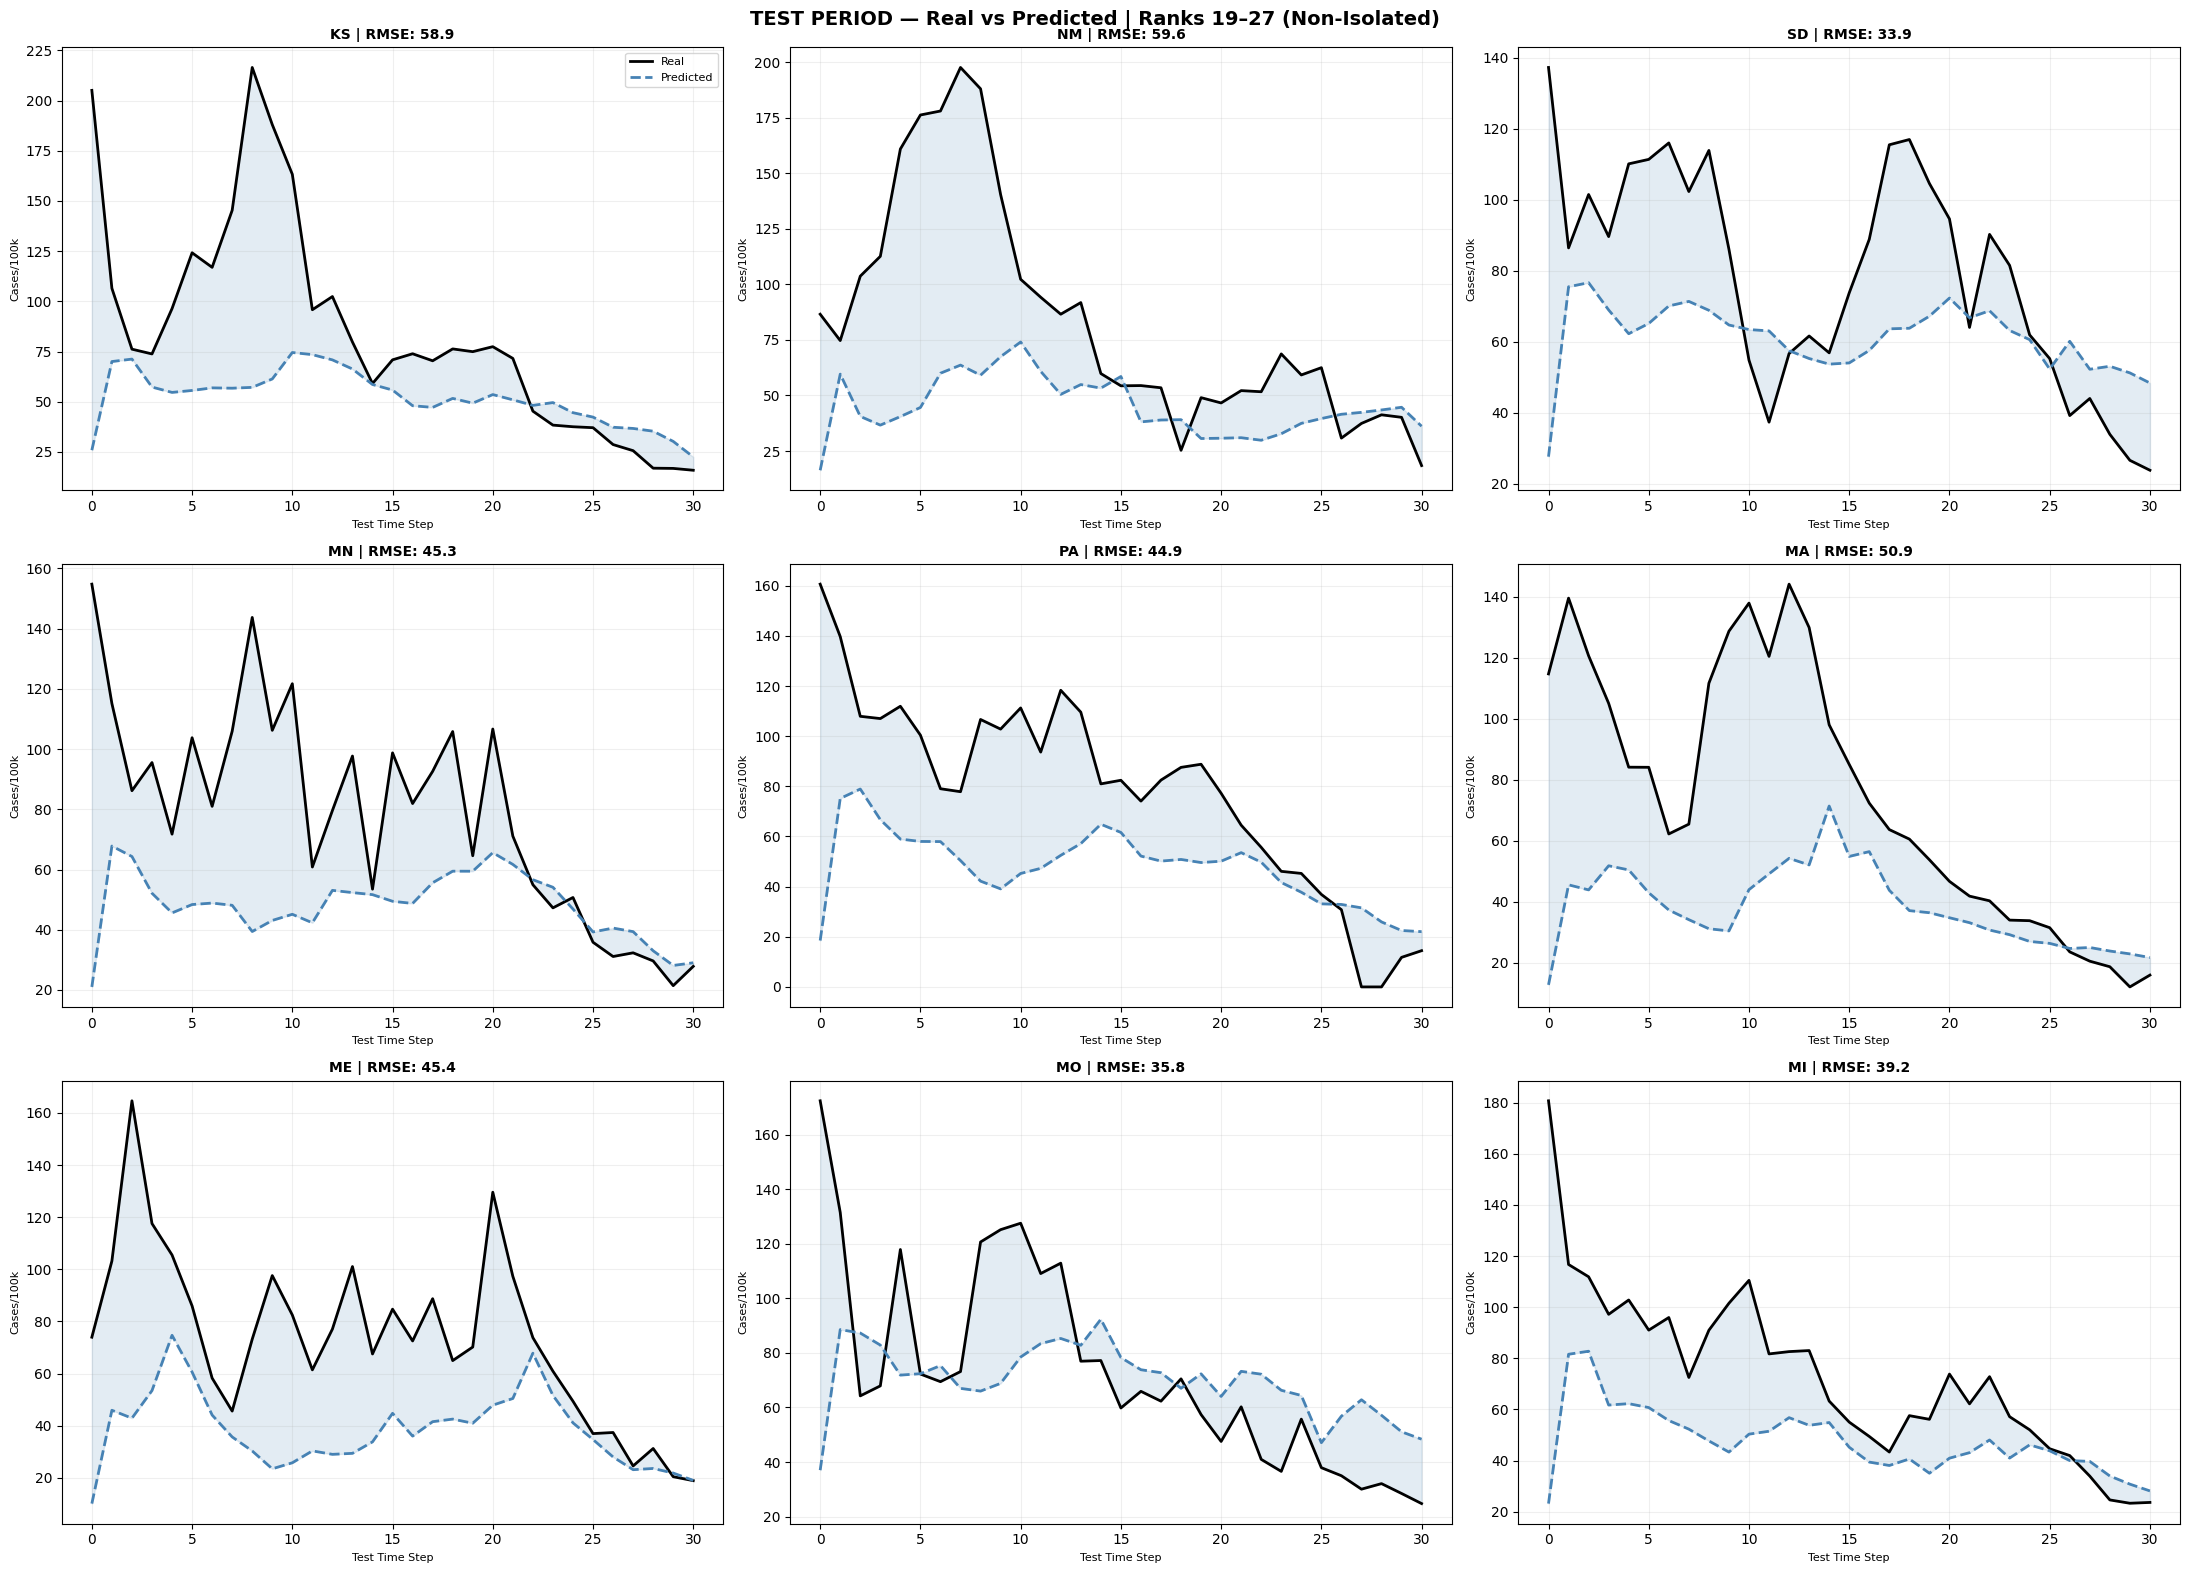

Plot for ranks 19–27 created.


In [48]:
# CELL – Next 9 non-isolated states (ranks 19–27)


# isolated states to skip
ISOLATED = {"PR", "AK", "HI", "GU", "VI", "MP", "AS"}

# build full non-isolated ranking first
test_state_mean_all = (
    test_metrics["detail"]
    [~test_metrics["detail"]["state"].isin(ISOLATED)]
    .groupby("state", as_index=False)["ytrue"].mean()
    .sort_values("ytrue", ascending=False)
    .reset_index(drop=True)
)

print("Full non-isolated state ranking:")
print(test_state_mean_all[["state", "ytrue"]].to_string())

# change these to see any group of 9
start_rank = 18
end_rank   = 27

next9_states = test_state_mean_all.iloc[start_rank:end_rank]["state"].tolist()
print("\nPlotting states:", next9_states)

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
axes = axes.flatten()

for i, st in enumerate(next9_states):
    stdf = (
        test_metrics["detail"]
        [test_metrics["detail"]["state"] == st]
        .groupby("date", as_index=False)
        .agg(ytrue=("ytrue", "mean"), ypred=("ypred", "mean"))
        .sort_values("date")
    )

    x = range(len(stdf))
    ax = axes[i]

    ax.plot(x, stdf["ytrue"].values, color="black", linewidth=2, label="Real")
    ax.plot(
        x,
        stdf["ypred"].values,
        color="steelblue",
        linestyle="--",
        linewidth=2,
        label="Predicted",
    )
    ax.fill_between(
        x,
        stdf["ytrue"].values,
        stdf["ypred"].values,
        color="steelblue",
        alpha=0.15,
    )

    rmse_st = np.sqrt(mean_squared_error(stdf["ytrue"], stdf["ypred"]))
    ax.set_title(f"{st} | RMSE: {rmse_st:.1f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Test Time Step", fontsize=8)
    ax.set_ylabel("Cases/100k", fontsize=8)
    ax.grid(alpha=0.2)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

for j in range(len(next9_states), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"TEST PERIOD — Real vs Predicted | Ranks {start_rank+1}–{end_rank} (Non-Isolated)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
print(f"Plot for ranks {start_rank+1}–{end_rank} created.")

Plotting states: ['NH', 'IN', 'CA', 'AR', 'CT', 'TX', 'NE', 'MT', 'MD']


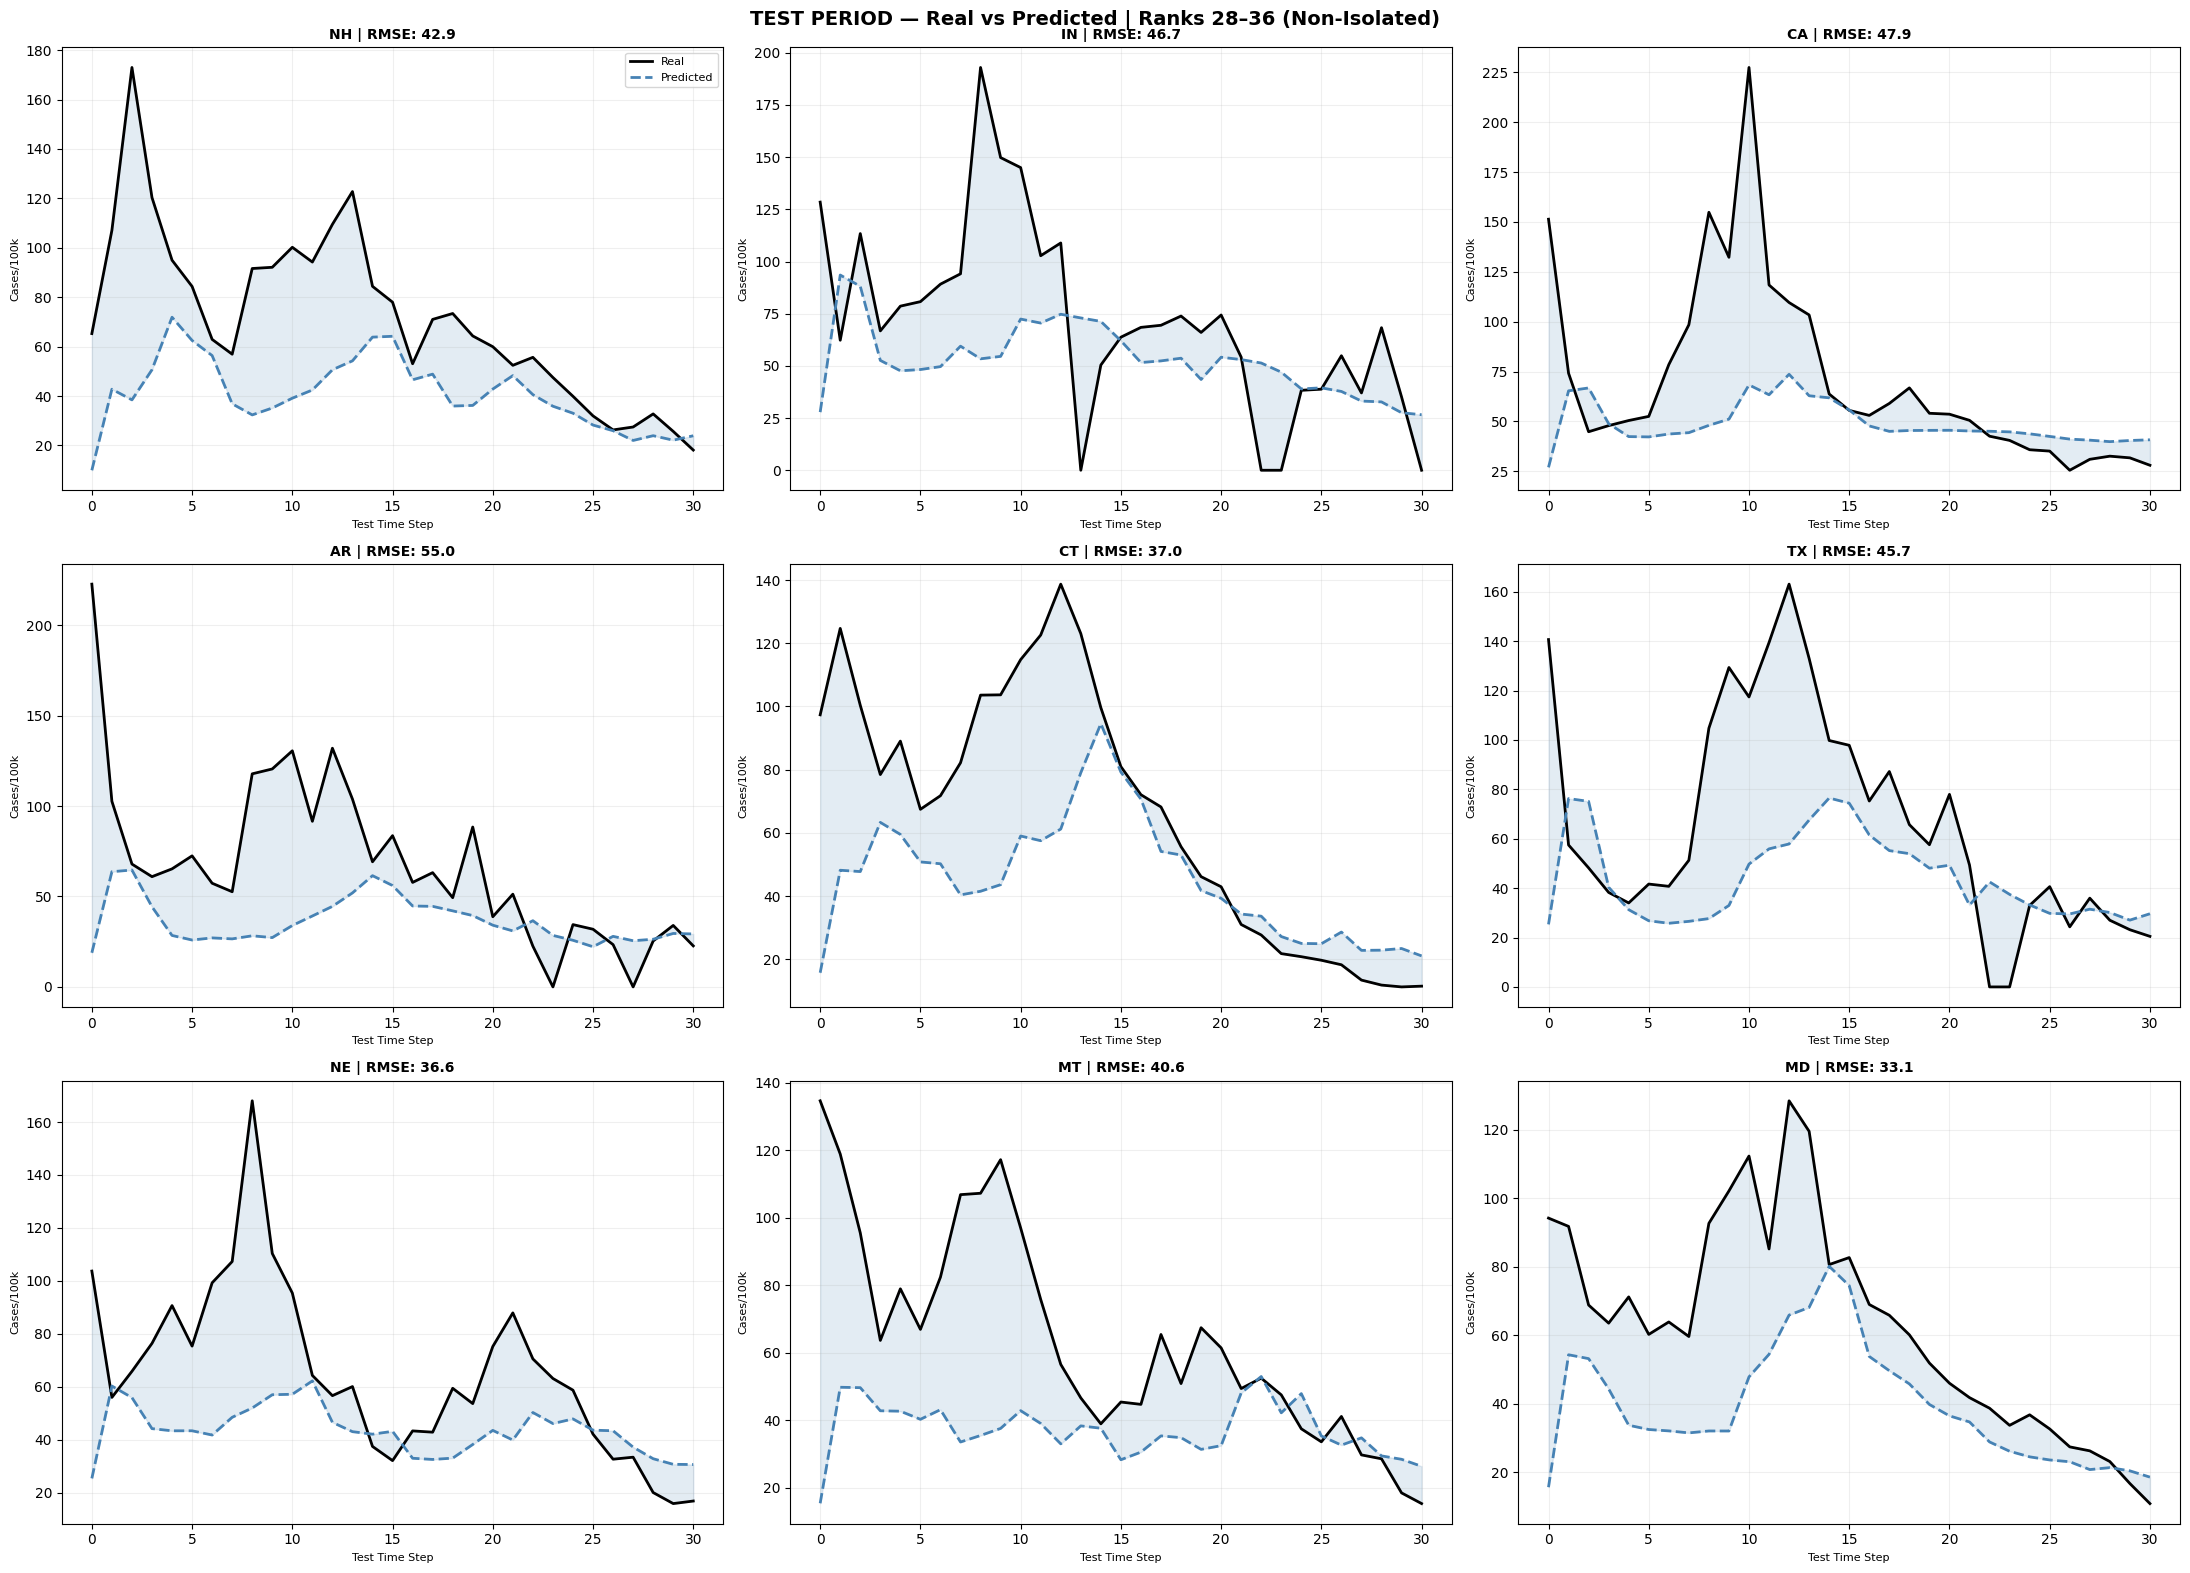

Plot for ranks 28–36 created.


In [49]:
# CELL – TEST period, real vs predicted for NEXT 9 states (Ranks 28–36)


ISOLATED = {"PR", "AK", "HI", "GU", "VI", "MP", "AS"}

test_state_mean_all = (
    test_metrics["detail"]
    [~test_metrics["detail"]["state"].isin(ISOLATED)]
    .groupby("state", as_index=False)["ytrue"].mean()
    .sort_values("ytrue", ascending=False)
    .reset_index(drop=True)
)

# ranks 28–36
start_rank = 27
end_rank   = 36

next9_states = test_state_mean_all.iloc[start_rank:end_rank]["state"].tolist()
print("Plotting states:", next9_states)

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
axes = axes.flatten()

for i, st in enumerate(next9_states):
    stdf = (
        test_metrics["detail"]
        [test_metrics["detail"]["state"] == st]
        .groupby("date", as_index=False)
        .agg(ytrue=("ytrue", "mean"), ypred=("ypred", "mean"))
        .sort_values("date")
    )

    x = range(len(stdf))
    ax = axes[i]

    ax.plot(x, stdf["ytrue"].values, color="black", linewidth=2, label="Real")
    ax.plot(
        x,
        stdf["ypred"].values,
        color="steelblue",
        linestyle="--",
        linewidth=2,
        label="Predicted",
    )
    ax.fill_between(
        x,
        stdf["ytrue"].values,
        stdf["ypred"].values,
        color="steelblue",
        alpha=0.15,
    )

    rmse_st = np.sqrt(mean_squared_error(stdf["ytrue"], stdf["ypred"]))
    ax.set_title(f"{st} | RMSE: {rmse_st:.1f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Test Time Step", fontsize=8)
    ax.set_ylabel("Cases/100k", fontsize=8)
    ax.grid(alpha=0.2)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

for j in range(len(next9_states), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"TEST PERIOD — Real vs Predicted | Ranks {start_rank+1}–{end_rank} (Non-Isolated)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
print(f"Plot for ranks {start_rank+1}–{end_rank} created.")

Plotting states: ['CO', 'MS', 'WY', 'FL', 'OR', 'IA', 'GA', 'WA', 'VT']


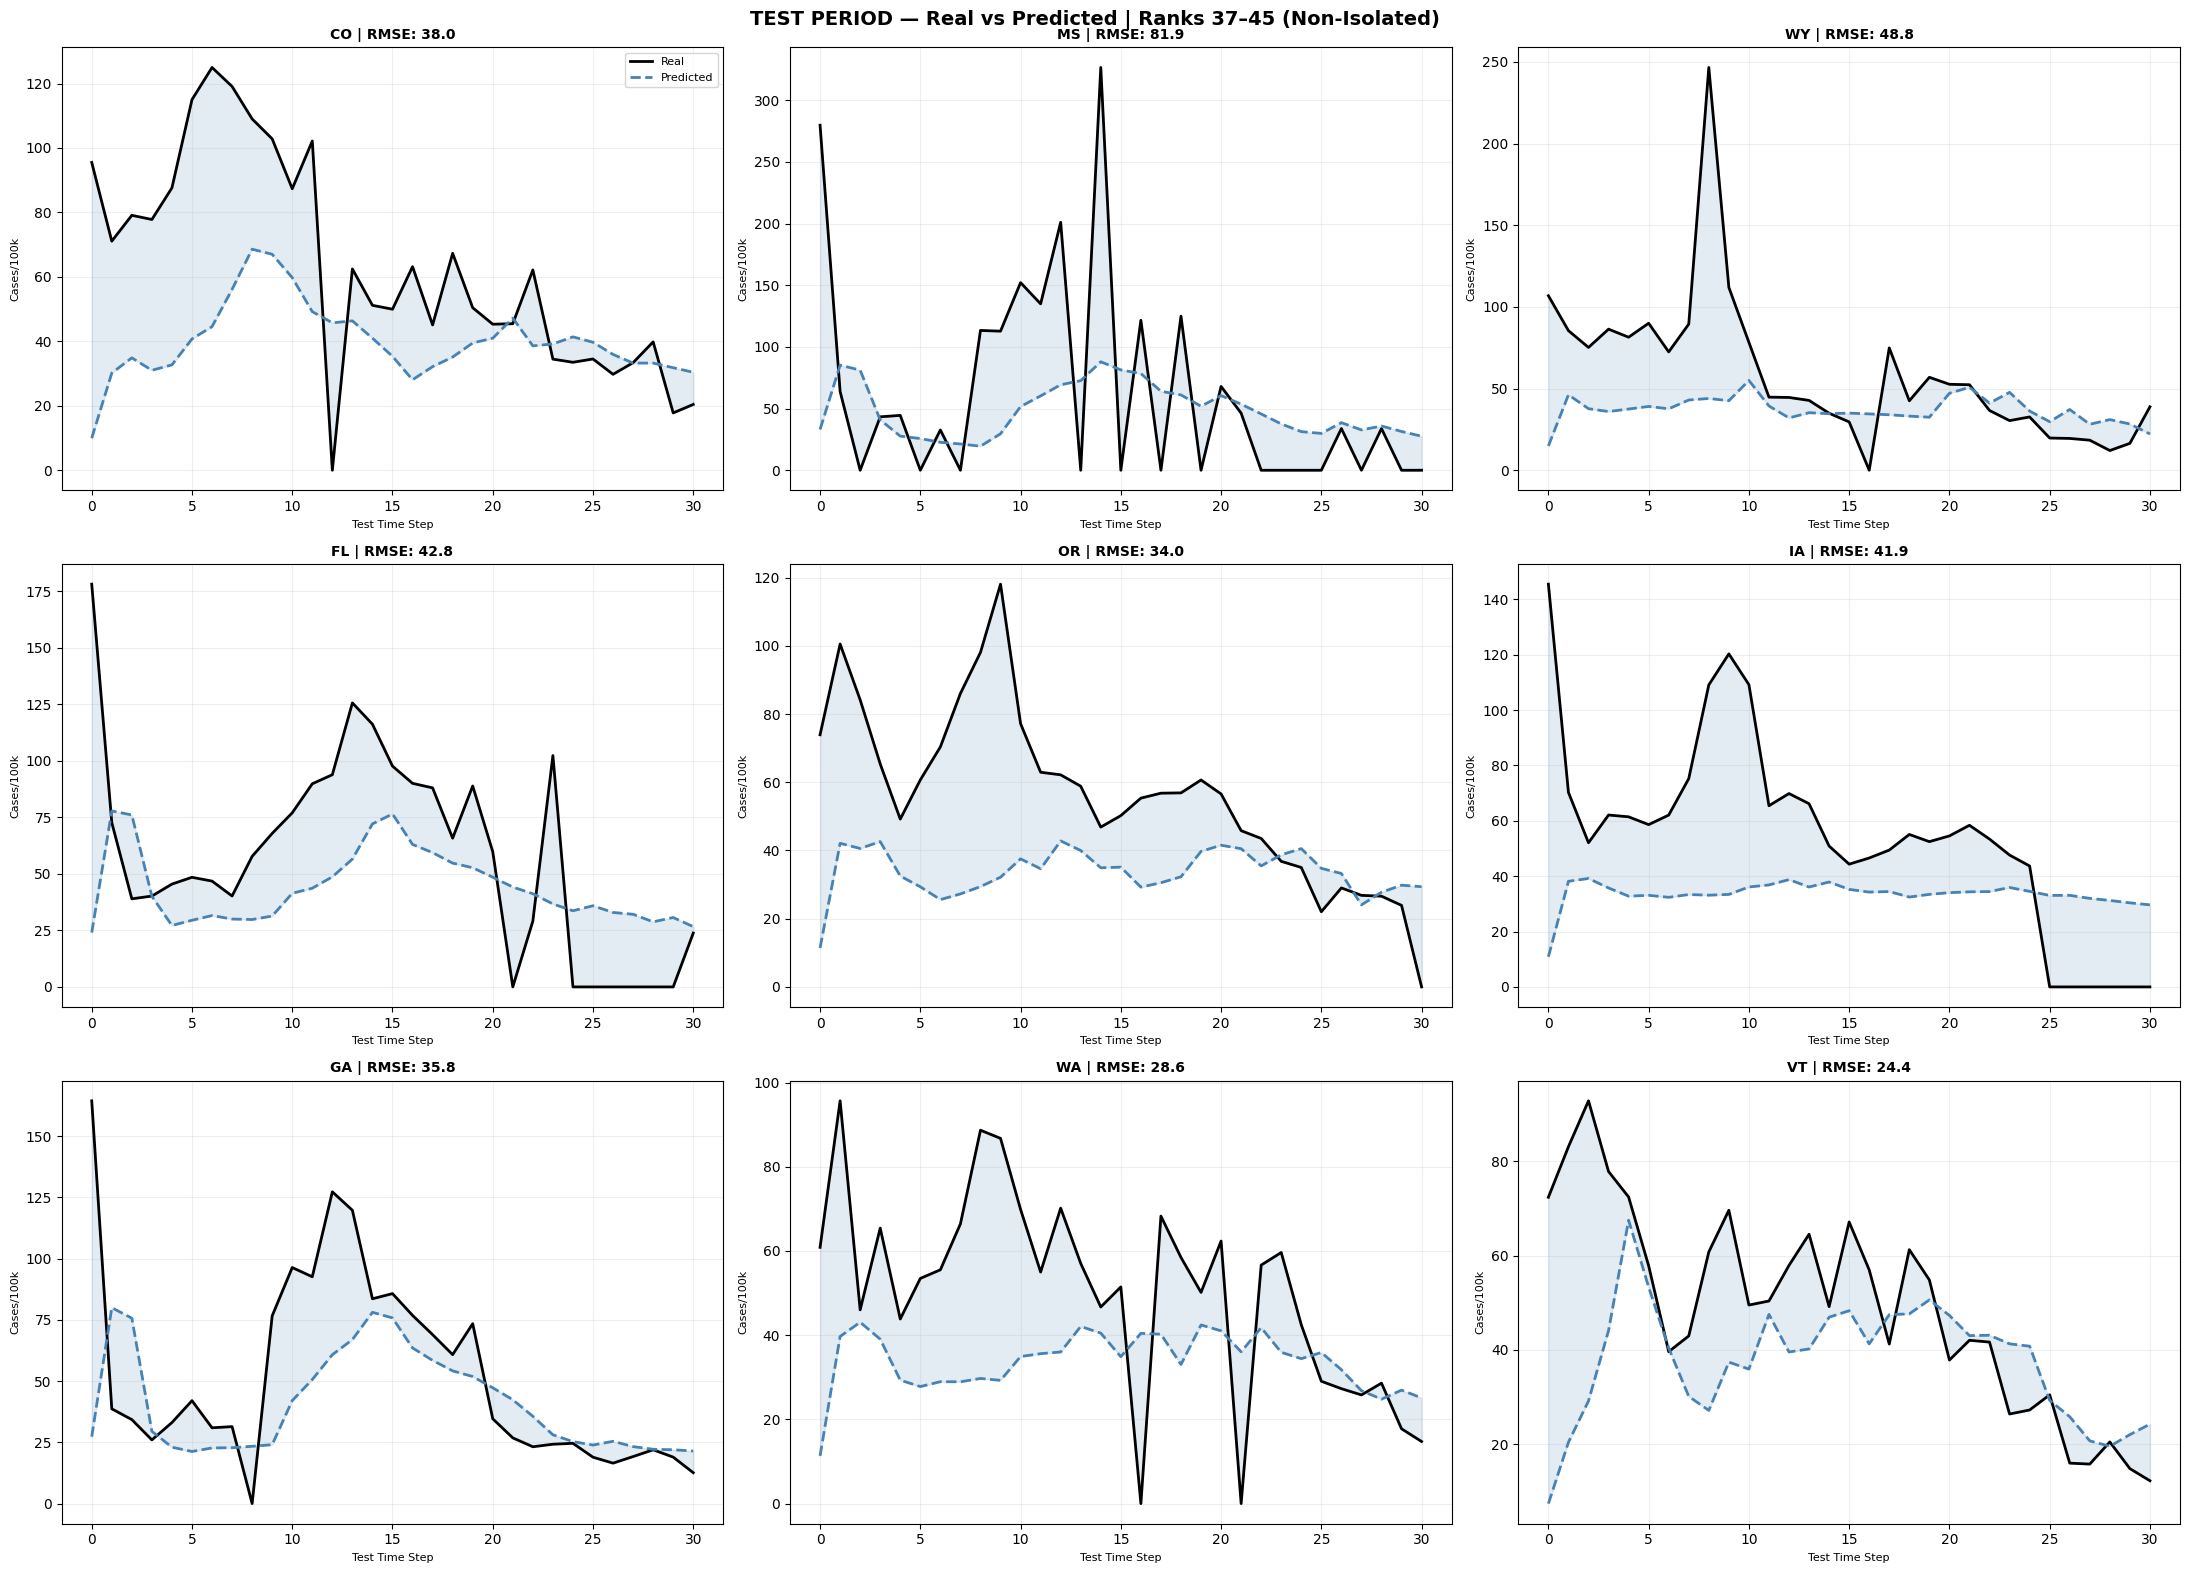

Plot for ranks 37–45 created.


In [50]:
# CELL – TEST period, real vs predicted for NEXT 9 states (Ranks 37–45)


ISOLATED = {"PR", "AK", "HI", "GU", "VI", "MP", "AS"}

test_state_mean_all = (
    test_metrics["detail"]
    [~test_metrics["detail"]["state"].isin(ISOLATED)]
    .groupby("state", as_index=False)["ytrue"].mean()
    .sort_values("ytrue", ascending=False)
    .reset_index(drop=True)
)

# ranks 37–45
start_rank = 36
end_rank   = 45

next9_states = test_state_mean_all.iloc[start_rank:end_rank]["state"].tolist()
print("Plotting states:", next9_states)

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
axes = axes.flatten()

for i, st in enumerate(next9_states):
    stdf = (
        test_metrics["detail"]
        [test_metrics["detail"]["state"] == st]
        .groupby("date", as_index=False)
        .agg(ytrue=("ytrue", "mean"), ypred=("ypred", "mean"))
        .sort_values("date")
    )

    x = range(len(stdf))
    ax = axes[i]

    ax.plot(x, stdf["ytrue"].values, color="black", linewidth=2, label="Real")
    ax.plot(
        x,
        stdf["ypred"].values,
        color="steelblue",
        linestyle="--",
        linewidth=2,
        label="Predicted",
    )
    ax.fill_between(
        x,
        stdf["ytrue"].values,
        stdf["ypred"].values,
        color="steelblue",
        alpha=0.15,
    )

    rmse_st = np.sqrt(mean_squared_error(stdf["ytrue"], stdf["ypred"]))
    ax.set_title(f"{st} | RMSE: {rmse_st:.1f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Test Time Step", fontsize=8)
    ax.set_ylabel("Cases/100k", fontsize=8)
    ax.grid(alpha=0.2)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

for j in range(len(next9_states), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"TEST PERIOD — Real vs Predicted | Ranks {start_rank+1}–{end_rank} (Non-Isolated)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
print(f"Plot for ranks {start_rank+1}–{end_rank} created.")

Plotting states: ['ID', 'DC', 'UT', 'NV']


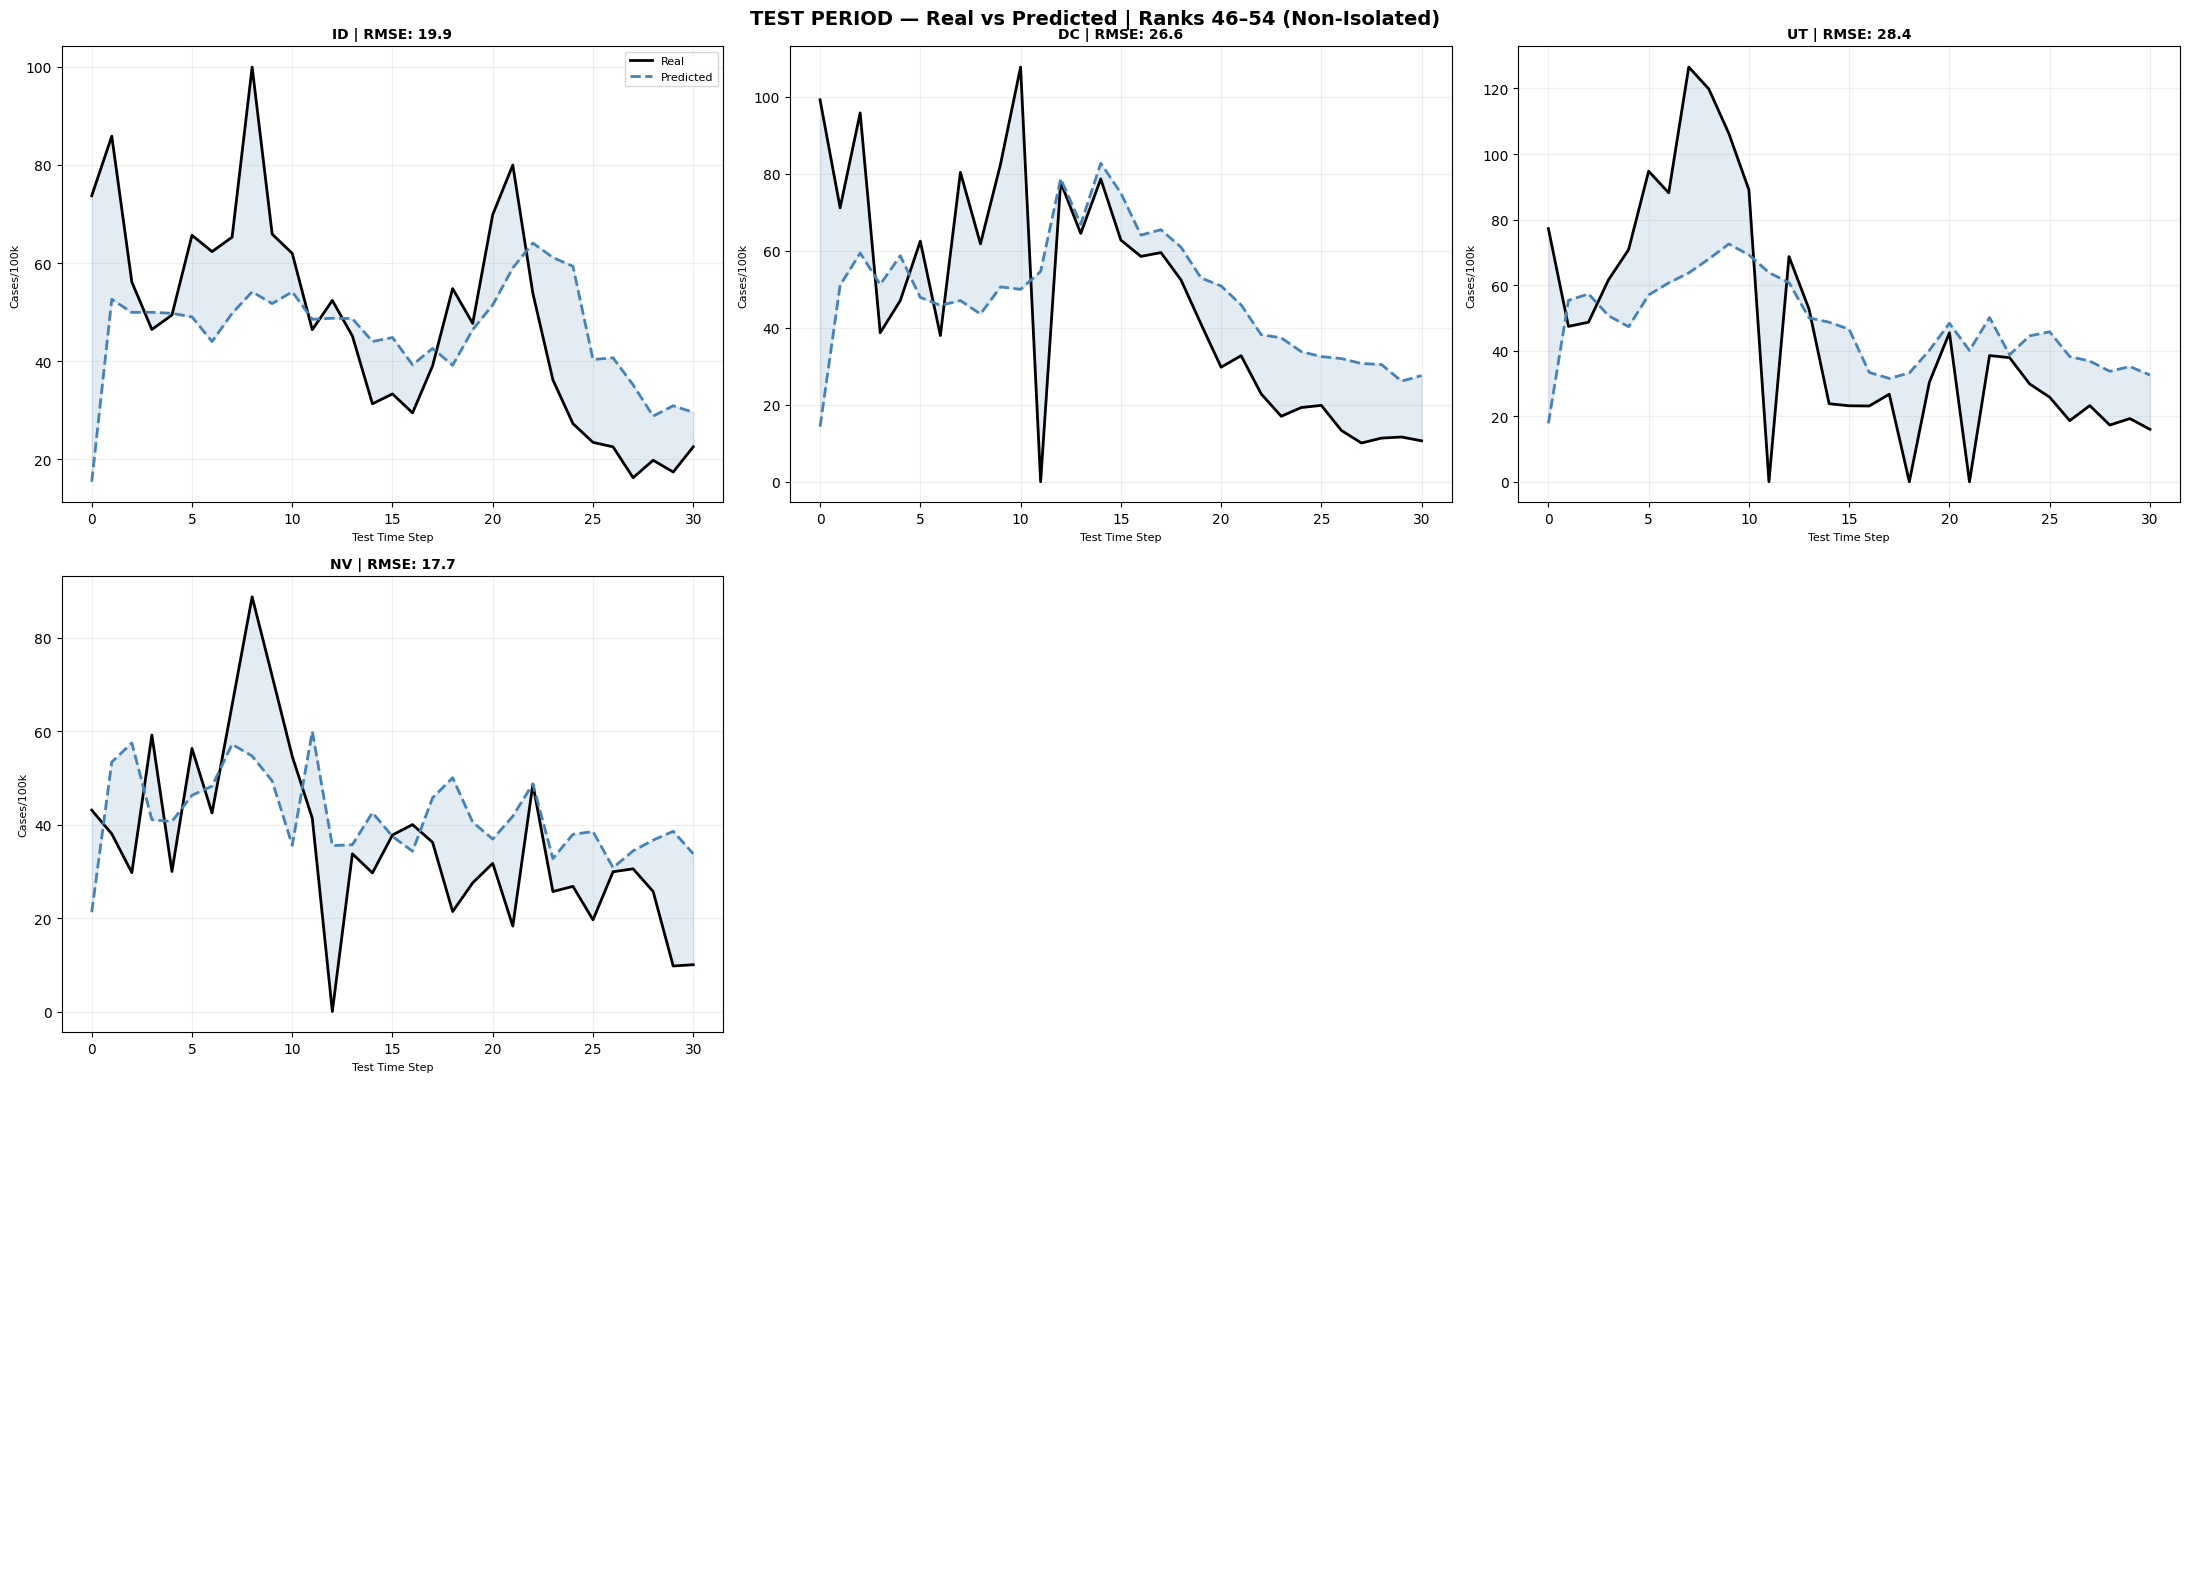

Plot for ranks 46–54 created.


In [51]:
# CELL – Ranks 46–54


ISOLATED = {"PR", "AK", "HI", "GU", "VI", "MP", "AS"}

test_state_mean_all = (
    test_metrics["detail"]
    [~test_metrics["detail"]["state"].isin(ISOLATED)]
    .groupby("state", as_index=False)["ytrue"].mean()
    .sort_values("ytrue", ascending=False)
    .reset_index(drop=True)
)

start_rank = 45
end_rank   = 54

next9_states = test_state_mean_all.iloc[start_rank:end_rank]["state"].tolist()
print("Plotting states:", next9_states)

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
axes = axes.flatten()

for i, st in enumerate(next9_states):
    stdf = (
        test_metrics["detail"]
        [test_metrics["detail"]["state"] == st]
        .groupby("date", as_index=False)
        .agg(ytrue=("ytrue", "mean"), ypred=("ypred", "mean"))
        .sort_values("date")
    )

    x = range(len(stdf))
    ax = axes[i]

    ax.plot(x, stdf["ytrue"].values, color="black", linewidth=2, label="Real")
    ax.plot(
        x,
        stdf["ypred"].values,
        color="steelblue",
        linestyle="--",
        linewidth=2,
        label="Predicted",
    )
    ax.fill_between(
        x,
        stdf["ytrue"].values,
        stdf["ypred"].values,
        color="steelblue",
        alpha=0.15,
    )

    rmse_st = np.sqrt(mean_squared_error(stdf["ytrue"], stdf["ypred"]))
    ax.set_title(f"{st} | RMSE: {rmse_st:.1f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Test Time Step", fontsize=8)
    ax.set_ylabel("Cases/100k", fontsize=8)
    ax.grid(alpha=0.2)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

for j in range(len(next9_states), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"TEST PERIOD — Real vs Predicted | Ranks {start_rank+1}–{end_rank} (Non-Isolated)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
print(f"Plot for ranks {start_rank+1}–{end_rank} created.")

States: 53 | Time steps: 31
Unique state border pairs: 107
Edges analyzed: 107
 u  v     corr  lag_u_to_v  lag_v_to_u  net_direction
GA SC 0.983975    0.784250    0.723146       0.061104
CT RI 0.980256    0.856007    0.825677       0.030330
LA MS 0.972825    0.693938    0.753804      -0.059866
NC VA 0.971802    0.726691    0.864794      -0.138103
FL GA 0.967822    0.606207    0.768745      -0.162538
MA RI 0.961836    0.796563    0.782929       0.013634
CT MA 0.960422    0.806459    0.789871       0.016588
VA WV 0.957849    0.779211    0.651453       0.127758
TN VA 0.955453    0.693953    0.747177      -0.053224
DE MD 0.953096    0.714600    0.852145      -0.137545
edge_df, rolling_df, node_impact_df built OK


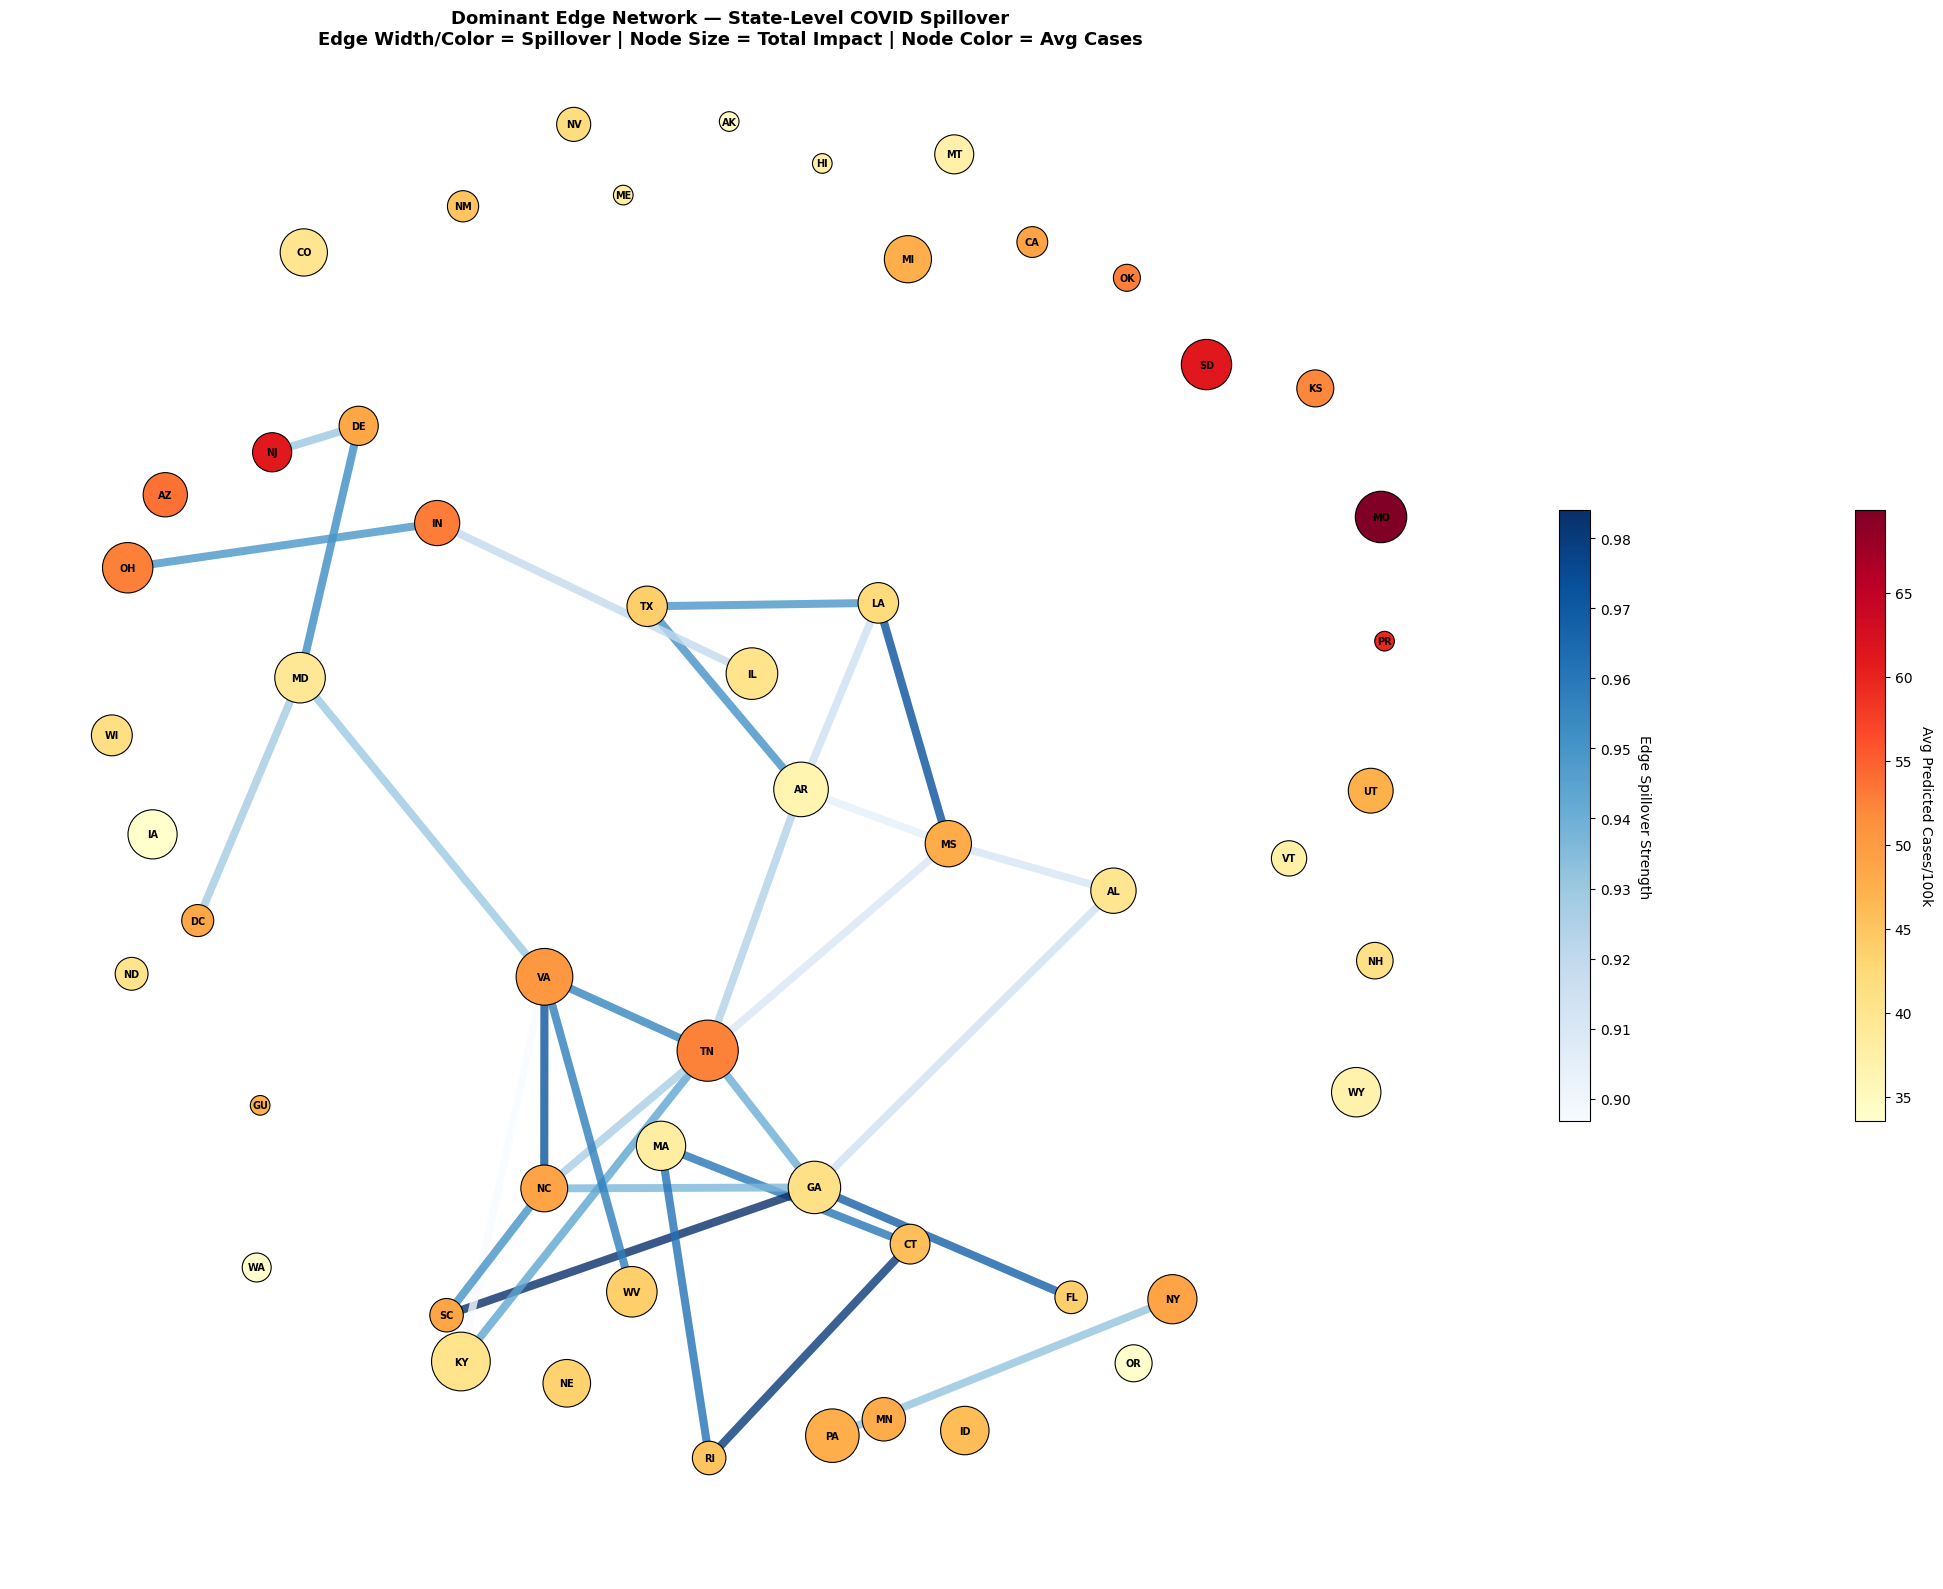

Plot 1 saved


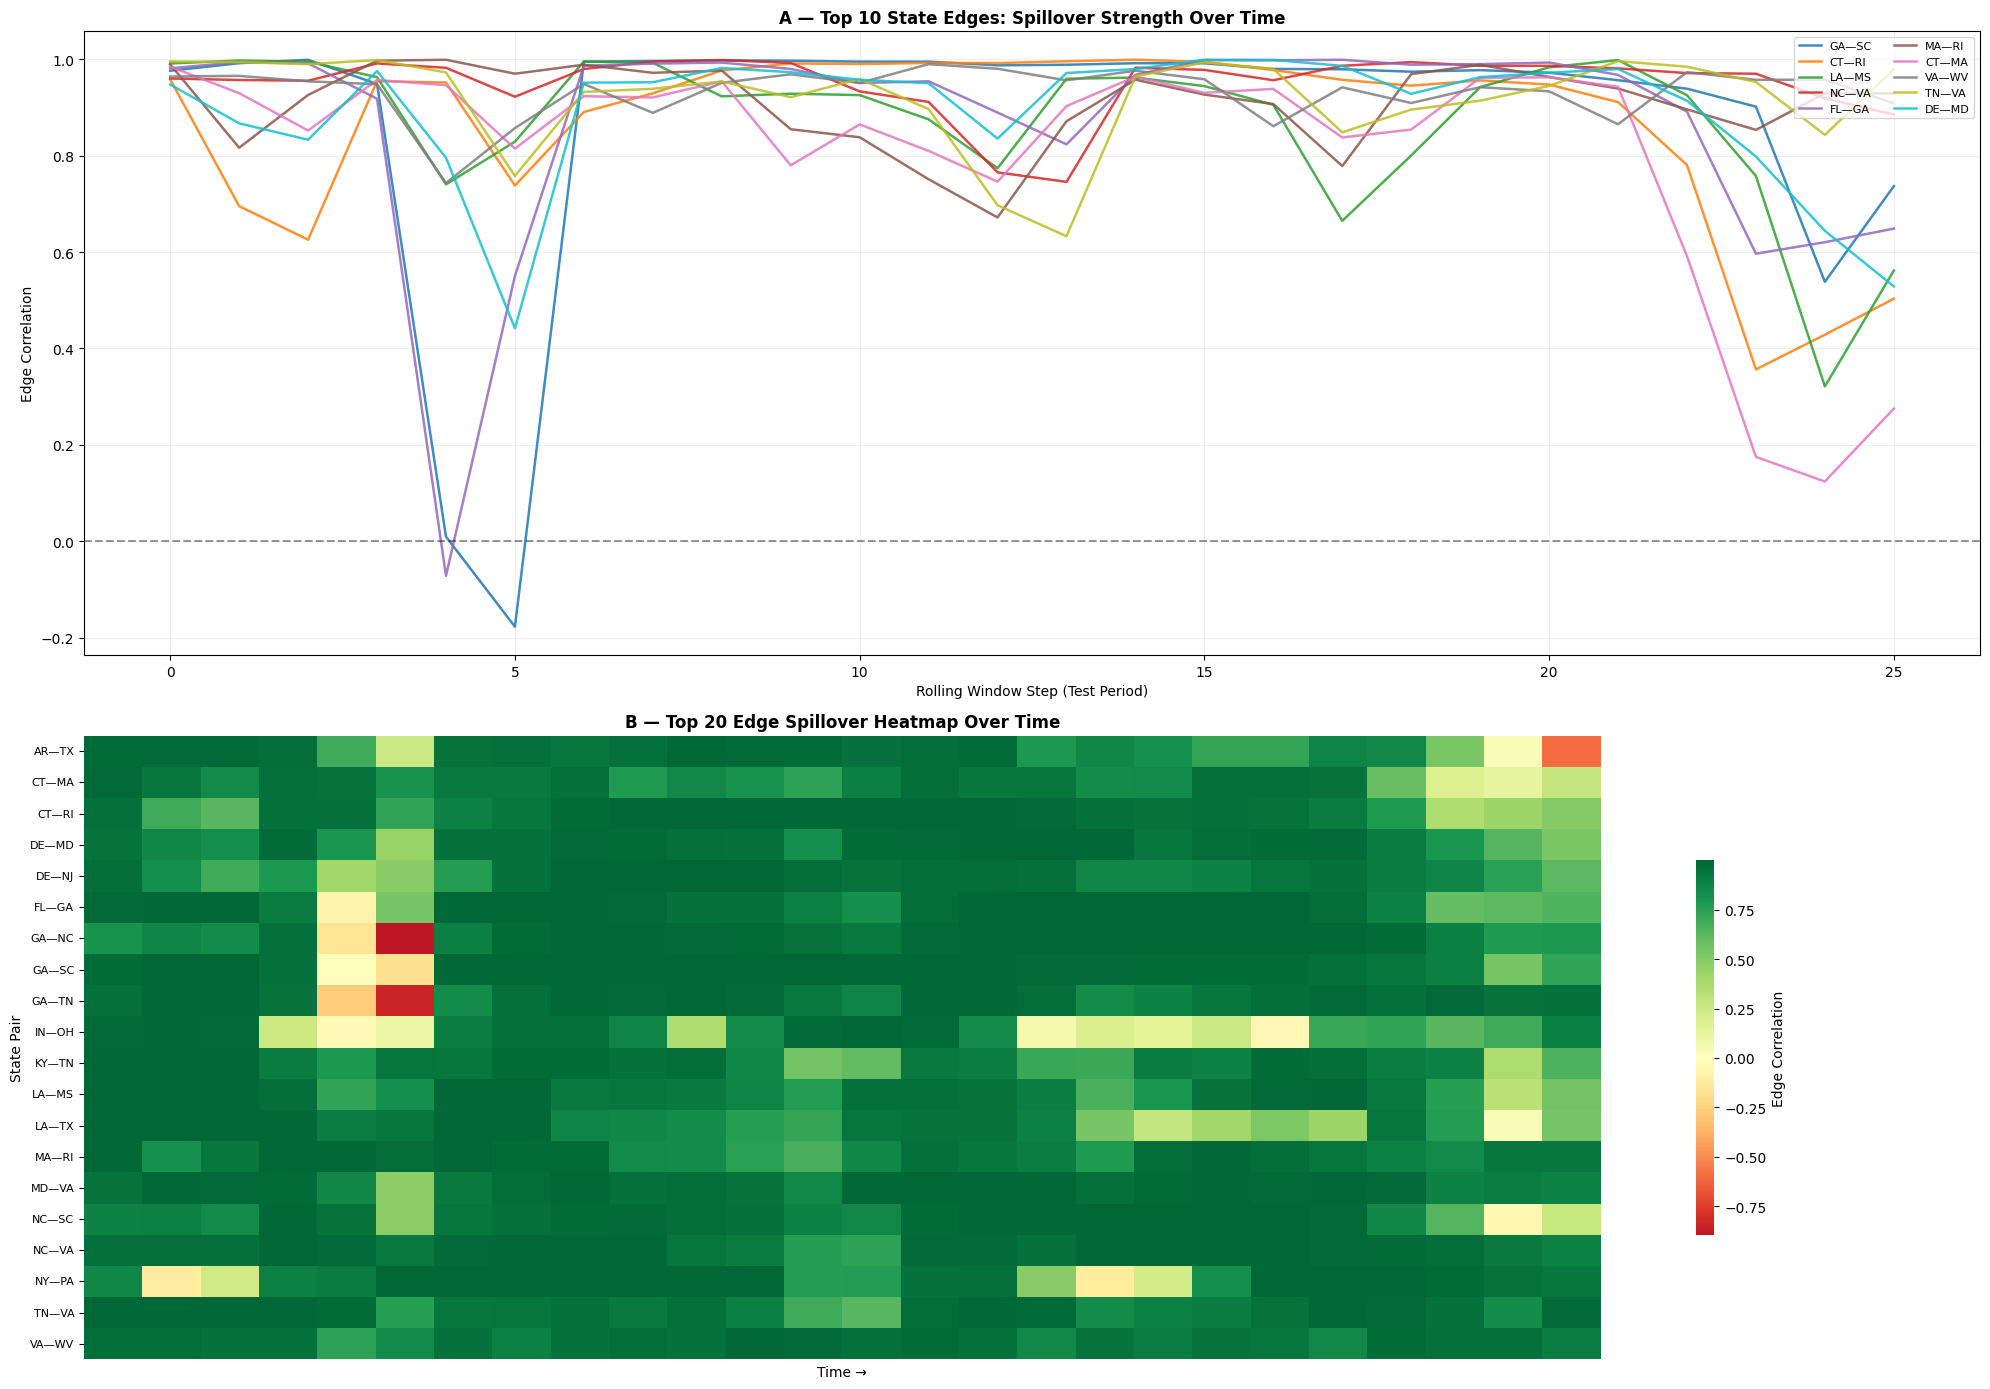

Plot 2 saved


In [52]:
# EDGE ANALYSIS – ALL PLOTS IN ONE CELL
# Run recovery cell first, then run this


# ── 1. State time series ──────────────────────────────────
county_results = test_metrics["detail"].copy()
county_results["date"] = pd.to_datetime(county_results["date"])

state_pred = (
    county_results
    .groupby(["date", "state"], as_index=False)
    .agg(pred=("ypred", "mean"), true=("ytrue", "mean"))
)
state_avg = (
    state_pred
    .groupby("state", as_index=False)
    .agg(avg_pred=("pred", "mean"), peak_pred=("pred", "max"))
)
state_avg_dict = state_avg.set_index("state")["avg_pred"].to_dict()

state_pred_ts = (
    state_pred
    .pivot(index="date", columns="state", values="pred")
    .sort_index().fillna(0)
)
states_in_ts = list(state_pred_ts.columns)
dates_list   = list(state_pred_ts.index)
T_total      = len(dates_list)
print(f"States: {len(states_in_ts)} | Time steps: {T_total}")

# ── 2. State adjacency ────────────────────────────────────
fips_to_state = county_lookup.set_index("fips")["state"].to_dict()

state_edges_raw = interstate_edges_df.copy()
state_edges_raw["state"]          = state_edges_raw["fips"].map(fips_to_state)
state_edges_raw["neighbor_state"] = state_edges_raw["neighborfips"].map(fips_to_state)
state_edges_raw = state_edges_raw.dropna(subset=["state", "neighbor_state"])
state_edges_raw = state_edges_raw[
    state_edges_raw["state"] != state_edges_raw["neighbor_state"]]

state_edges_df2 = state_edges_raw[["state", "neighbor_state"]].drop_duplicates().copy()
state_edges_df2["u"] = state_edges_df2[["state", "neighbor_state"]].min(axis=1)
state_edges_df2["v"] = state_edges_df2[["state", "neighbor_state"]].max(axis=1)
state_edges_df2 = state_edges_df2.drop_duplicates(subset=["u", "v"])[["u", "v"]]
print(f"Unique state border pairs: {len(state_edges_df2)}")

# ── 3. Edge weights ───────────────────────────────────────
edge_records = []
for _, row in state_edges_df2.iterrows():
    u, v = row["u"], row["v"]
    if u not in states_in_ts or v not in states_in_ts:
        continue
    ts_u = state_pred_ts[u].values
    ts_v = state_pred_ts[v].values
    corr   = float(np.corrcoef(ts_u, ts_v)[0, 1]) if (
        ts_u.std() > 0 and ts_v.std() > 0) else 0.0
    lag_uv = float(np.corrcoef(ts_u[:-1], ts_v[1:])[0, 1]) if (
        ts_u[:-1].std() > 0 and ts_v[1:].std() > 0) else 0.0
    lag_vu = float(np.corrcoef(ts_v[:-1], ts_u[1:])[0, 1]) if (
        ts_v[:-1].std() > 0 and ts_u[1:].std() > 0) else 0.0
    edge_records.append({
        "u": u, "v": v,
        "corr": corr,
        "lag_u_to_v": lag_uv,
        "lag_v_to_u": lag_vu,
        "net_direction": lag_uv - lag_vu,
        "edge_label": f"{u}—{v}"
    })

edge_df = pd.DataFrame(edge_records).sort_values(
    "corr", ascending=False).reset_index(drop=True)
print(f"Edges analyzed: {len(edge_df)}")
print(edge_df[["u","v","corr","lag_u_to_v",
               "lag_v_to_u","net_direction"]].head(10).to_string(index=False))

# ── 4. Rolling edge weights ───────────────────────────────
WINDOW = 5
top20_labels = edge_df.head(20)["edge_label"].tolist()
rolling_records = []
for wi in range(WINDOW, T_total):
    win_dates = dates_list[wi - WINDOW:wi]
    ts_win = state_pred_ts.loc[win_dates]
    for _, erow in edge_df.head(20).iterrows():
        u, v = erow["u"], erow["v"]
        if u not in ts_win.columns or v not in ts_win.columns:
            continue
        su = ts_win[u].values
        sv = ts_win[v].values
        w = float(np.corrcoef(su, sv)[0, 1]) if (
            su.std() > 0 and sv.std() > 0) else 0.0
        rolling_records.append({
            "date": dates_list[wi],
            "edge": erow["edge_label"],
            "weight": w
        })
rolling_df = pd.DataFrame(rolling_records)

# ── 5. Node impact ────────────────────────────────────────
node_impact = {}
for st in states_in_ts:
    mask = (edge_df["u"] == st) | (edge_df["v"] == st)
    node_impact[st] = edge_df[mask]["corr"].sum()

node_impact_df = (
    pd.DataFrame([{"state": k, "impact_score": v}
                  for k, v in node_impact.items()])
    .sort_values("impact_score", ascending=False)
    .reset_index(drop=True)
)

print("edge_df, rolling_df, node_impact_df built OK")

# ══════════════════════════════════════════════════════════
# PLOT 1 – Dominant Edge Network
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(22, 16))
G_edge = nx.Graph()
for st in states_in_ts:
    G_edge.add_node(st)
for _, erow in edge_df.head(30).iterrows():
    G_edge.add_edge(erow["u"], erow["v"], weight=erow["corr"])

pos_e = nx.spring_layout(G_edge, seed=42, k=0.7)
ns = [min(max(node_impact.get(n, 0) * 300, 200), 4000) for n in G_edge.nodes()]
nc_vals = [state_avg_dict.get(n, 0) for n in G_edge.nodes()]
nc_norm = Normalize(vmin=min(nc_vals), vmax=max(nc_vals))
nc_colors = [plt.cm.YlOrRd(nc_norm(v)) for v in nc_vals]
edge_weights = [G_edge[u][v]["weight"] for u, v in G_edge.edges()]
ew_norm = Normalize(vmin=min(edge_weights), vmax=max(edge_weights))
edge_colors = [plt.cm.Blues(ew_norm(w)) for w in edge_weights]
edge_widths = [1 + w * 5 for w in edge_weights]

nx.draw_networkx_edges(G_edge, pos_e, ax=ax,
    edge_color=edge_colors, width=edge_widths, alpha=0.8)
nx.draw_networkx_nodes(G_edge, pos_e, ax=ax,
    node_color=nc_colors, node_size=ns,
    edgecolors="black", linewidths=0.8)
nx.draw_networkx_labels(G_edge, pos_e, ax=ax,
    font_size=7, font_weight="bold")

sm1 = ScalarMappable(cmap=plt.cm.YlOrRd, norm=nc_norm); sm1.set_array([])
cb1 = fig.colorbar(sm1, ax=ax, shrink=0.4, pad=0.01, location="right")
cb1.set_label("Avg Predicted Cases/100k", rotation=270, labelpad=15, fontsize=10)
sm2 = ScalarMappable(cmap=plt.cm.Blues, norm=ew_norm); sm2.set_array([])
cb2 = fig.colorbar(sm2, ax=ax, shrink=0.4, pad=0.06, location="right")
cb2.set_label("Edge Spillover Strength", rotation=270, labelpad=15, fontsize=10)

ax.set_title(
    "Dominant Edge Network — State-Level COVID Spillover\n"
    "Edge Width/Color = Spillover | Node Size = Total Impact | Node Color = Avg Cases",
    fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "dominant_edge_network.png"),
    dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved")

# ══════════════════════════════════════════════════════════
# PLOT 2 – Edge Evolution Over Time
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(20, 14))

ax1 = axes[0]
colors_l = plt.cm.tab10(np.linspace(0, 1, 10))
for i, el in enumerate(edge_df.head(10)["edge_label"].tolist()):
    sub = rolling_df[rolling_df["edge"] == el].sort_values("date")
    if len(sub) > 0:
        ax1.plot(range(len(sub)), sub["weight"].values,
            label=el, linewidth=1.8, color=colors_l[i], alpha=0.85)
ax1.axhline(y=0, color="black", linestyle="--", alpha=0.4)
ax1.set_title(
    "A — Top 10 State Edges: Spillover Strength Over Time",
    fontsize=12, fontweight="bold")
ax1.set_xlabel("Rolling Window Step (Test Period)", fontsize=10)
ax1.set_ylabel("Edge Correlation", fontsize=10)
ax1.legend(fontsize=8, ncol=2, loc="upper right")
ax1.grid(alpha=0.2)

ax2 = axes[1]
pivot_roll = (
    rolling_df[rolling_df["edge"].isin(top20_labels)]
    .pivot_table(index="edge", columns="date", values="weight")
    .fillna(0)
)
pivot_sampled = pivot_roll.iloc[:, ::max(1, len(pivot_roll.columns) // 20)]
sns.heatmap(pivot_sampled, cmap="RdYlGn", ax=ax2, center=0,
    xticklabels=False, yticklabels=True,
    cbar_kws={"label": "Edge Correlation", "shrink": 0.6})
ax2.set_title(
    "B — Top 20 Edge Spillover Heatmap Over Time",
    fontsize=12, fontweight="bold")
ax2.set_xlabel("Time →", fontsize=10)
ax2.set_ylabel("State Pair", fontsize=10)
ax2.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "edge_evolution_over_time.png"),
    dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved")

In [53]:
# =====================================================================================
# FULL COUNTERFACTUAL PEAK-TREATMENT LAB
# DOMINANT-FEATURE + GRAVITY-TARGETED SPILLOVER VERSION
# MULTI-FEATURE DELTA SUPPORT
# ROBUST FIPS + COUNTY COLUMN FIX
# Compatible with trained notebook objects from GNN-modeling.ipynb
# =====================================================================================

import ipywidgets as widgets



# -------------------------------------------------
# 1. Robust metadata helpers
# -------------------------------------------------

def ensure_column(df, preferred_names, fallback_contains=None, final_name=None, required=True):
    lower_map = {c.lower(): c for c in df.columns}

    for name in preferred_names:
        if name.lower() in lower_map:
            found = lower_map[name.lower()]
            if final_name is not None and found != final_name:
                df = df.rename(columns={found: final_name})
                found = final_name
            return df, found

    if fallback_contains is not None:
        for c in df.columns:
            if fallback_contains.lower() in c.lower():
                found = c
                if final_name is not None and found != final_name:
                    df = df.rename(columns={found: final_name})
                    found = final_name
                return df, found

    if required:
        raise ValueError(f"Could not find any of {preferred_names} in columns: {list(df.columns)}")
    return df, None


def detect_county_col_safe(df):
    candidates = []
    for c in df.columns:
        cl = c.lower().strip()
        if cl in ["county", "county_name", "name", "cty", "counties"]:
            candidates.append(c)

    if candidates:
        return candidates[0]

    excluded = {
        "state", "fips", "statefips", "state_fips",
        "node_id", "idx", "index", "neighborfips", "neighbor_fips"
    }
    fallback = [c for c in df.columns if c.lower().strip() not in excluded]

    if fallback:
        return fallback[0]

    return None


# -------------------------------------------------
# 2. Normalize county_lookup first
# -------------------------------------------------

county_lookup_clean = county_lookup.copy()

county_lookup_clean, _ = ensure_column(
    county_lookup_clean,
    preferred_names=["fips"],
    fallback_contains="fip",
    final_name="fips",
    required=True
)

county_lookup_clean["fips"] = (
    county_lookup_clean["fips"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .str.zfill(5)
)

county_lookup_clean, _ = ensure_column(
    county_lookup_clean,
    preferred_names=["state"],
    fallback_contains="state",
    final_name="state",
    required=True
)

COUNTY_COL_NAME = detect_county_col_safe(county_lookup_clean)

if COUNTY_COL_NAME is None or COUNTY_COL_NAME.lower().strip() == "fips":
    county_lookup_clean["county_label"] = county_lookup_clean["fips"].astype(str)
    COUNTY_COL_NAME = "county_label"

available_states = sorted(county_lookup_clean["state"].dropna().astype(str).unique().tolist())
available_features = sorted(lag_feature_cols)

target_lag_regex = re.compile(rf"^{re.escape(TARGET_COL)}_lag(\d+)$", re.IGNORECASE)
target_lag_map = {}
for i, col in enumerate(lag_feature_cols):
    m = target_lag_regex.match(col)
    if m:
        target_lag_map[int(m.group(1))] = i

target_lag_steps = sorted(target_lag_map.keys())
if len(target_lag_steps) == 0:
    raise ValueError(f"No target lag columns found for TARGET_COL={TARGET_COL}")

print("Detected county column:", COUNTY_COL_NAME)
print("Detected target lag map:", target_lag_map)

fips_to_state = county_lookup_clean.set_index("fips")["state"].astype(str).to_dict()
fips_to_county = county_lookup_clean.set_index("fips")[COUNTY_COL_NAME].astype(str).to_dict()


# -------------------------------------------------
# 3. Node metadata helpers
# -------------------------------------------------

def node_to_fips(node_id):
    if int(node_id) in idx_to_county:
        return str(idx_to_county[int(node_id)]).zfill(5)
    return None


def node_to_meta(node_id):
    fips = node_to_fips(node_id)
    return {
        "node_id": int(node_id),
        "fips": fips,
        "state": fips_to_state.get(fips, None),
        "county": fips_to_county.get(fips, None),
    }


# -------------------------------------------------
# 4. Scaling helpers
# -------------------------------------------------

def scale_feature_vector(raw_tensor, feature_name):
    mu = float(train_means[feature_name])
    sd = float(train_stds[feature_name]) if float(train_stds[feature_name]) != 0 else 1.0
    return (raw_tensor - mu) / sd


def unscale_feature_vector(scaled_tensor, feature_name):
    mu = float(train_means[feature_name])
    sd = float(train_stds[feature_name]) if float(train_stds[feature_name]) != 0 else 1.0
    return scaled_tensor * sd + mu


# -------------------------------------------------
# 5. Region helpers
# -------------------------------------------------

def get_region_nodes(selected_state, selected_county):
    if selected_county == "ALL COUNTIES":
        fips_list = county_lookup_clean.loc[
            county_lookup_clean["state"].astype(str) == str(selected_state), "fips"
        ].tolist()
    else:
        fips_list = county_lookup_clean.loc[
            (county_lookup_clean["state"].astype(str) == str(selected_state)) &
            (county_lookup_clean[COUNTY_COL_NAME].astype(str) == str(selected_county)),
            "fips"
        ].tolist()

    node_ids = [county_to_idx[f] for f in fips_list if f in county_to_idx]
    return sorted(node_ids)


def make_region_mask(node_ids):
    mask = torch.zeros(n_nodes, dtype=torch.bool, device=DEVICE)
    if len(node_ids) > 0:
        mask[node_ids] = True
    return mask


# -------------------------------------------------
# 6. Graph neighbor helpers
# -------------------------------------------------

def get_neighbor_nodes_from_edges(treated_nodes, include_intra=True, include_inter=True):
    treated_set = set(treated_nodes)
    neighbor_set = set()

    edge_sources = []
    if include_intra:
        edge_sources.append(("intra", edge_index_intra))
    if include_inter:
        edge_sources.append(("inter", edge_index_inter))

    for edge_type, edge_index in edge_sources:
        src = edge_index[0].detach().cpu().tolist()
        dst = edge_index[1].detach().cpu().tolist()

        for s, t in zip(src, dst):
            if s in treated_set and t not in treated_set:
                neighbor_set.add(t)
            if t in treated_set and s not in treated_set:
                neighbor_set.add(s)

    return sorted(neighbor_set)


def build_boundary_edge_table(treated_nodes, node_mean_change, include_intra=True, include_inter=True):
    treated_set = set(treated_nodes)
    rows = []

    edge_sources = []
    if include_intra:
        edge_sources.append(("intra", edge_index_intra))
    if include_inter:
        edge_sources.append(("inter", edge_index_inter))

    for edge_type, edge_index in edge_sources:
        src = edge_index[0].detach().cpu().tolist()
        dst = edge_index[1].detach().cpu().tolist()

        for s, t in zip(src, dst):
            s_treated = s in treated_set
            t_treated = t in treated_set

            if s_treated ^ t_treated:
                treated_node = s if s_treated else t
                neighbor_node = t if s_treated else s

                treated_meta = node_to_meta(treated_node)
                neighbor_meta = node_to_meta(neighbor_node)

                rows.append({
                    "edge_type": edge_type,
                    "treated_node_id": int(treated_node),
                    "treated_fips": treated_meta["fips"],
                    "treated_state": treated_meta["state"],
                    "treated_county": treated_meta["county"],
                    "neighbor_node_id": int(neighbor_node),
                    "neighbor_fips": neighbor_meta["fips"],
                    "neighbor_state": neighbor_meta["state"],
                    "neighbor_county": neighbor_meta["county"],
                    "neighbor_mean_change": float(node_mean_change[neighbor_node]),
                    "neighbor_abs_change": float(abs(node_mean_change[neighbor_node])),
                })

    edge_df = pd.DataFrame(rows)
    if len(edge_df) == 0:
        return edge_df

    edge_df = edge_df.sort_values(
        ["neighbor_abs_change", "neighbor_mean_change"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return edge_df


# -------------------------------------------------
# 7. Baseline rollout
# -------------------------------------------------

def run_baseline_rollout():
    model.eval()
    h = torch.zeros((n_nodes, HIDDEN_DIM), device=DEVICE)
    preds = {}
    with torch.no_grad():
        for d in sorted(test_snaps.keys()):
            snap = test_snaps[d]
            y_hat_log, h = model.forward_step(
                snap["x"], h, snap["active"], edge_index_intra, edge_index_inter
            )
            preds[d] = torch.expm1(y_hat_log).clamp(min=0)
    return preds


BASELINE_CACHE = run_baseline_rollout()


def get_region_series(pred_dict, region_nodes):
    dates = sorted(pred_dict.keys())
    series = []
    region_mask = make_region_mask(region_nodes)
    for d in dates:
        snap = test_snaps[d]
        live_mask = region_mask & snap["mask"]
        if live_mask.sum() == 0:
            series.append(np.nan)
        else:
            series.append(float(pred_dict[d][live_mask].mean().detach().cpu()))
    return dates, np.array(series, dtype=float)


# -------------------------------------------------
# 8. Baseline node burden + degree + gravity
# -------------------------------------------------

def get_degrees():
    intra_src = edge_index_intra[0].detach().cpu().numpy()
    intra_dst = edge_index_intra[1].detach().cpu().numpy()
    inter_src = edge_index_inter[0].detach().cpu().numpy()
    inter_dst = edge_index_inter[1].detach().cpu().numpy()

    intra_deg = np.zeros(n_nodes, dtype=float)
    inter_deg = np.zeros(n_nodes, dtype=float)

    for s in intra_src:
        intra_deg[s] += 1.0
    for s in inter_src:
        inter_deg[s] += 1.0

    return intra_deg, inter_deg


INTRA_DEG, INTER_DEG = get_degrees()


def get_baseline_node_means():
    node_sum = torch.zeros(n_nodes, device=DEVICE)
    node_count = torch.zeros(n_nodes, device=DEVICE)

    for d in sorted(BASELINE_CACHE.keys()):
        snap = test_snaps[d]
        y = BASELINE_CACHE[d]
        active_mask_f = snap["mask"].float()
        node_sum += y * active_mask_f
        node_count += active_mask_f

    node_mean = (node_sum / torch.clamp(node_count, min=1.0)).detach().cpu().numpy()
    return node_mean


BASELINE_NODE_MEAN = get_baseline_node_means()


def build_node_gravity_table(selected_state):
    rows = []
    selected_state = str(selected_state)

    for nid in range(n_nodes):
        meta = node_to_meta(nid)
        if meta["state"] != selected_state:
            continue

        gravity_score = (
            0.60 * float(BASELINE_NODE_MEAN[nid]) +
            0.25 * float(INTRA_DEG[nid]) +
            0.15 * float(INTER_DEG[nid])
        )

        rows.append({
            "node_id": int(nid),
            "fips": meta["fips"],
            "state": meta["state"],
            "county": meta["county"],
            "baseline_mean": float(BASELINE_NODE_MEAN[nid]),
            "intra_degree": float(INTRA_DEG[nid]),
            "inter_degree": float(INTER_DEG[nid]),
            "gravity_score": float(gravity_score),
        })

    out = pd.DataFrame(rows)
    if len(out) > 0:
        out = out.sort_values(
            ["gravity_score", "baseline_mean", "inter_degree"],
            ascending=[False, False, False]
        ).reset_index(drop=True)
    return out


def build_neighbor_state_gravity_table(treated_nodes):
    treated_set = set(treated_nodes)
    exposure_counts = {}

    src = edge_index_inter[0].detach().cpu().tolist()
    dst = edge_index_inter[1].detach().cpu().tolist()

    for s, t in zip(src, dst):
        if s in treated_set and t not in treated_set:
            exposure_counts[t] = exposure_counts.get(t, 0) + 1
        if t in treated_set and s not in treated_set:
            exposure_counts[s] = exposure_counts.get(s, 0) + 1

    rows = []
    for nid, edge_ct in exposure_counts.items():
        meta = node_to_meta(nid)
        gravity_score = (
            0.55 * float(BASELINE_NODE_MEAN[nid]) +
            0.20 * float(INTRA_DEG[nid]) +
            0.25 * float(edge_ct)
        )
        rows.append({
            "node_id": int(nid),
            "fips": meta["fips"],
            "state": meta["state"],
            "county": meta["county"],
            "baseline_mean": float(BASELINE_NODE_MEAN[nid]),
            "intra_degree": float(INTRA_DEG[nid]),
            "treated_border_exposure": int(edge_ct),
            "gravity_score": float(gravity_score),
        })

    out = pd.DataFrame(rows)
    if len(out) > 0:
        out = out.sort_values(
            ["gravity_score", "treated_border_exposure", "baseline_mean"],
            ascending=[False, False, False]
        ).reset_index(drop=True)
    return out


def select_top_state_nodes(selected_state, candidate_nodes, top_k):
    gravity_df = build_node_gravity_table(selected_state)
    if len(gravity_df) == 0:
        return [], gravity_df

    candidate_set = set(candidate_nodes)
    gravity_df = gravity_df[gravity_df["node_id"].isin(candidate_set)].copy()
    gravity_df = gravity_df.sort_values(
        ["gravity_score", "baseline_mean", "inter_degree"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    top_nodes = gravity_df.head(int(top_k))["node_id"].astype(int).tolist()
    return top_nodes, gravity_df


def select_top_neighbor_nodes(treated_nodes, candidate_neighbor_nodes, top_k):
    gravity_df = build_neighbor_state_gravity_table(treated_nodes)
    if len(gravity_df) == 0:
        return [], gravity_df

    candidate_set = set(candidate_neighbor_nodes)
    gravity_df = gravity_df[gravity_df["node_id"].isin(candidate_set)].copy()
    gravity_df = gravity_df.sort_values(
        ["gravity_score", "treated_border_exposure", "baseline_mean"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    top_nodes = gravity_df.head(int(top_k))["node_id"].astype(int).tolist()
    return top_nodes, gravity_df


# -------------------------------------------------
# 9. Multi-feature helpers
# -------------------------------------------------

def clean_feature_delta_map(feature_delta_map):
    if feature_delta_map is None:
        return {}

    clean_map = {}
    for feat, delta in feature_delta_map.items():
        if feat is None:
            continue
        feat = str(feat).strip()
        if feat in ["", "NONE", "AUTO DOMINANT FEATURE"]:
            continue
        if feat not in lag_feature_cols:
            continue
        if delta is None:
            continue
        if float(delta) == 0.0:
            continue
        clean_map[feat] = float(delta)
    return clean_map


def apply_feature_deltas(x_cf, treated_mask, feature_delta_map, policy_mode="multiplicative"):
    if feature_delta_map is None or len(feature_delta_map) == 0:
        return x_cf

    for feat, delta in feature_delta_map.items():
        feat_idx = lag_feature_cols.index(feat)

        if policy_mode == "multiplicative":
            x_cf[treated_mask, feat_idx] = x_cf[treated_mask, feat_idx] * (1.0 + float(delta))
        elif policy_mode == "additive_sd":
            x_cf[treated_mask, feat_idx] = x_cf[treated_mask, feat_idx] + float(delta)
        else:
            raise ValueError("policy_mode must be 'multiplicative' or 'additive_sd'")

    return x_cf


def format_feature_delta_map(feature_delta_map):
    feature_delta_map = clean_feature_delta_map(feature_delta_map)
    if len(feature_delta_map) == 0:
        return "None"
    return ", ".join([f"{k}: {v:+.0%}" if abs(v) <= 2 else f"{k}: {v:+.2f}" for k, v in feature_delta_map.items()])


# -------------------------------------------------
# 10. Counterfactual engine
# -------------------------------------------------

def run_counterfactual(
    selected_state,
    selected_county,
    treatment_feature=None,
    delta_pct=0.0,
    feature_delta_map=None,
    peak_half_width=2,
    start_shift=0,
    region_only_autoreg=True,
    policy_mode="multiplicative",
    include_intra_neighbors=True,
    include_inter_neighbors=True,
    use_top_state_targeting=False,
    top_state_k=10,
    use_top_neighbor_targeting=False,
    top_neighbor_k=10,
):
    model.eval()

    if treatment_feature is not None:
        if treatment_feature not in lag_feature_cols:
            raise ValueError(f"{treatment_feature} not found in lag_feature_cols")

    feature_delta_map = clean_feature_delta_map(feature_delta_map)

    if treatment_feature is not None and treatment_feature != "AUTO DOMINANT FEATURE":
        if treatment_feature not in feature_delta_map:
            feature_delta_map = dict(feature_delta_map)
            feature_delta_map[treatment_feature] = float(delta_pct)

    treated_nodes_full = get_region_nodes(selected_state, selected_county)
    if len(treated_nodes_full) == 0:
        raise ValueError("No valid treated nodes found for this state/county selection.")

    if use_top_state_targeting:
        treated_nodes, state_gravity_df = select_top_state_nodes(
            selected_state=selected_state,
            candidate_nodes=treated_nodes_full,
            top_k=top_state_k
        )
        if len(treated_nodes) == 0:
            treated_nodes = treated_nodes_full
    else:
        treated_nodes = treated_nodes_full
        state_gravity_df = build_node_gravity_table(selected_state)
        state_gravity_df = state_gravity_df[state_gravity_df["node_id"].isin(treated_nodes_full)].reset_index(drop=True)

    neighbor_nodes_full = get_neighbor_nodes_from_edges(
        treated_nodes,
        include_intra=include_intra_neighbors,
        include_inter=include_inter_neighbors
    )

    if use_top_neighbor_targeting:
        neighbor_nodes, neighbor_gravity_df = select_top_neighbor_nodes(
            treated_nodes=treated_nodes,
            candidate_neighbor_nodes=neighbor_nodes_full,
            top_k=top_neighbor_k
        )
        if len(neighbor_nodes) == 0:
            neighbor_nodes = neighbor_nodes_full
    else:
        neighbor_nodes = neighbor_nodes_full
        neighbor_gravity_df = build_neighbor_state_gravity_table(treated_nodes)
        neighbor_gravity_df = neighbor_gravity_df[
            neighbor_gravity_df["node_id"].isin(neighbor_nodes_full)
        ].reset_index(drop=True)

    treated_mask_global = make_region_mask(treated_nodes)
    neighbor_mask_global = make_region_mask(neighbor_nodes)
    far_rest_mask_global = ~(treated_mask_global | neighbor_mask_global)

    baseline_dates, baseline_region_series = get_region_series(BASELINE_CACHE, treated_nodes)
    peak_idx = int(np.nanargmax(baseline_region_series))

    start_idx = max(0, peak_idx - peak_half_width + start_shift)
    end_idx = min(len(baseline_dates) - 1, peak_idx + peak_half_width + start_shift)
    treatment_dates = set(baseline_dates[start_idx:end_idx + 1])

    h_base = torch.zeros((n_nodes, HIDDEN_DIM), device=DEVICE)
    h_cf = torch.zeros((n_nodes, HIDDEN_DIM), device=DEVICE)

    pred_hist_cf = []
    pred_hist_base = []

    base_region = []
    cf_region = []
    base_neighbors = []
    cf_neighbors = []
    base_far = []
    cf_far = []

    step_records = []

    node_base_sum = torch.zeros(n_nodes, device=DEVICE)
    node_cf_sum = torch.zeros(n_nodes, device=DEVICE)
    node_count = torch.zeros(n_nodes, device=DEVICE)

    with torch.no_grad():
        for d in sorted(test_snaps.keys()):
            snap = test_snaps[d]

            # Baseline pass
            y_hat_log_b, h_base = model.forward_step(
                snap["x"], h_base, snap["active"], edge_index_intra, edge_index_inter
            )
            y_pred_b = torch.expm1(y_hat_log_b).clamp(min=0)
            pred_hist_base.append(y_pred_b.clone())

            # Counterfactual input build
            x_cf = snap["x"].clone()

            update_nodes_mask = treated_mask_global.clone() if region_only_autoreg else torch.ones(
                n_nodes, dtype=torch.bool, device=DEVICE
            )

            for lag_step, lag_idx in target_lag_map.items():
                if len(pred_hist_cf) >= lag_step:
                    past_pred_raw = pred_hist_cf[-lag_step]
                    feature_name = lag_feature_cols[lag_idx]
                    scaled_past = scale_feature_vector(past_pred_raw, feature_name)
                    x_cf[update_nodes_mask, lag_idx] = scaled_past[update_nodes_mask]

            if d in treatment_dates:
                x_cf = apply_feature_deltas(
                    x_cf=x_cf,
                    treated_mask=treated_mask_global,
                    feature_delta_map=feature_delta_map,
                    policy_mode=policy_mode
                )

            # Counterfactual pass
            y_hat_log_cf, h_cf = model.forward_step(
                x_cf, h_cf, snap["active"], edge_index_intra, edge_index_inter
            )
            y_pred_cf = torch.expm1(y_hat_log_cf).clamp(min=0)
            pred_hist_cf.append(y_pred_cf.clone())

            # Aggregation
            live_treated = treated_mask_global & snap["mask"]
            live_neighbors = neighbor_mask_global & snap["mask"]
            live_far = far_rest_mask_global & snap["mask"]

            region_base_val = float(y_pred_b[live_treated].mean().detach().cpu()) if live_treated.sum() > 0 else np.nan
            region_cf_val = float(y_pred_cf[live_treated].mean().detach().cpu()) if live_treated.sum() > 0 else np.nan

            neighbor_base_val = float(y_pred_b[live_neighbors].mean().detach().cpu()) if live_neighbors.sum() > 0 else np.nan
            neighbor_cf_val = float(y_pred_cf[live_neighbors].mean().detach().cpu()) if live_neighbors.sum() > 0 else np.nan

            far_base_val = float(y_pred_b[live_far].mean().detach().cpu()) if live_far.sum() > 0 else np.nan
            far_cf_val = float(y_pred_cf[live_far].mean().detach().cpu()) if live_far.sum() > 0 else np.nan

            base_region.append(region_base_val)
            cf_region.append(region_cf_val)
            base_neighbors.append(neighbor_base_val)
            cf_neighbors.append(neighbor_cf_val)
            base_far.append(far_base_val)
            cf_far.append(far_cf_val)

            active_mask_f = snap["mask"].float()
            node_base_sum += y_pred_b * active_mask_f
            node_cf_sum += y_pred_cf * active_mask_f
            node_count += active_mask_f

            step_records.append({
                "date": pd.Timestamp(d),
                "treated_region_baseline_mean": region_base_val,
                "treated_region_counterfactual_mean": region_cf_val,
                "neighbor_region_baseline_mean": neighbor_base_val,
                "neighbor_region_counterfactual_mean": neighbor_cf_val,
                "far_region_baseline_mean": far_base_val,
                "far_region_counterfactual_mean": far_cf_val,
                "treatment_on": int(d in treatment_dates),
            })

    base_region = np.array(base_region, dtype=float)
    cf_region = np.array(cf_region, dtype=float)
    base_neighbors = np.array(base_neighbors, dtype=float)
    cf_neighbors = np.array(cf_neighbors, dtype=float)
    base_far = np.array(base_far, dtype=float)
    cf_far = np.array(cf_far, dtype=float)

    result_df = pd.DataFrame(step_records)

    node_mean_base = (node_base_sum / torch.clamp(node_count, min=1.0)).detach().cpu().numpy()
    node_mean_cf = (node_cf_sum / torch.clamp(node_count, min=1.0)).detach().cpu().numpy()
    node_mean_change = node_mean_cf - node_mean_base

    neighbor_impact_rows = []
    for nid in neighbor_nodes:
        meta = node_to_meta(nid)
        base_val = float(node_mean_base[nid])
        cf_val = float(node_mean_cf[nid])
        pct_change = 100.0 * (cf_val - base_val) / max(abs(base_val), 1e-8)

        neighbor_impact_rows.append({
            "node_id": int(nid),
            "fips": meta["fips"],
            "state": meta["state"],
            "county": meta["county"],
            "baseline_mean": base_val,
            "counterfactual_mean": cf_val,
            "mean_change": float(cf_val - base_val),
            "abs_change": float(abs(cf_val - base_val)),
            "pct_change": float(pct_change),
        })

    neighbor_impact_df = pd.DataFrame(neighbor_impact_rows)
    if len(neighbor_impact_df) > 0:
        neighbor_impact_df = neighbor_impact_df.sort_values(
            ["abs_change", "pct_change"],
            ascending=[False, False]
        ).reset_index(drop=True)

    edge_impact_df = build_boundary_edge_table(
        treated_nodes,
        node_mean_change,
        include_intra=include_intra_neighbors,
        include_inter=include_inter_neighbors
    )

    metrics = {
        "baseline_peak": float(np.nanmax(base_region)),
        "counterfactual_peak": float(np.nanmax(cf_region)),
        "baseline_peak_date": pd.Timestamp(sorted(test_snaps.keys())[int(np.nanargmax(base_region))]),
        "counterfactual_peak_date": pd.Timestamp(sorted(test_snaps.keys())[int(np.nanargmax(cf_region))]),
        "peak_reduction_pct": float(
            100.0 * (np.nanmax(base_region) - np.nanmax(cf_region)) / max(np.nanmax(base_region), 1e-8)
        ),
        "baseline_auc": float(np.nansum(base_region)),
        "counterfactual_auc": float(np.nansum(cf_region)),
        "auc_reduction_pct": float(
            100.0 * (np.nansum(base_region) - np.nansum(cf_region)) / max(np.nansum(base_region), 1e-8)
        ),
        "neighbor_spillover_mean_change_pct": float(
            100.0 * (np.nanmean(cf_neighbors) - np.nanmean(base_neighbors)) / max(abs(np.nanmean(base_neighbors)), 1e-8)
        ) if np.isfinite(np.nanmean(base_neighbors)) else np.nan,
        "far_spillover_mean_change_pct": float(
            100.0 * (np.nanmean(cf_far) - np.nanmean(base_far)) / max(abs(np.nanmean(base_far)), 1e-8)
        ) if np.isfinite(np.nanmean(base_far)) else np.nan,
        "peak_window_start": pd.Timestamp(baseline_dates[start_idx]),
        "peak_window_end": pd.Timestamp(baseline_dates[end_idx]),
        "n_treated_nodes": int(len(treated_nodes)),
        "n_neighbor_nodes": int(len(neighbor_nodes)),
        "gravity_treated_mean": float(state_gravity_df["gravity_score"].head(len(treated_nodes)).mean()) if len(state_gravity_df) else np.nan,
        "gravity_neighbor_mean": float(neighbor_gravity_df["gravity_score"].head(len(neighbor_nodes)).mean()) if len(neighbor_gravity_df) else np.nan,
        "feature_delta_map": dict(feature_delta_map),
    }

    return result_df, metrics, neighbor_impact_df, edge_impact_df, state_gravity_df, neighbor_gravity_df


# -------------------------------------------------
# 11. Dominant feature search
# -------------------------------------------------

def search_dominant_features(
    selected_state,
    selected_county,
    feature_list,
    deltas=(-0.7, -0.5, -0.3, -0.2, -0.1),
    peak_half_width_options=(1, 2, 3),
    start_shift_options=(-2, -1, 0, 1, 2),
    policy_mode="multiplicative",
    region_only_autoreg=True,
    include_intra_neighbors=True,
    include_inter_neighbors=True,
    use_top_state_targeting=False,
    top_state_k=10,
    use_top_neighbor_targeting=False,
    top_neighbor_k=10,
):
    rows = []

    for feat in feature_list:
        for delta in deltas:
            for w in peak_half_width_options:
                for shift in start_shift_options:
                    try:
                        _, m, _, _, _, _ = run_counterfactual(
                            selected_state=selected_state,
                            selected_county=selected_county,
                            treatment_feature=feat,
                            delta_pct=delta,
                            feature_delta_map=None,
                            peak_half_width=w,
                            start_shift=shift,
                            region_only_autoreg=region_only_autoreg,
                            policy_mode=policy_mode,
                            include_intra_neighbors=include_intra_neighbors,
                            include_inter_neighbors=include_inter_neighbors,
                            use_top_state_targeting=use_top_state_targeting,
                            top_state_k=top_state_k,
                            use_top_neighbor_targeting=use_top_neighbor_targeting,
                            top_neighbor_k=top_neighbor_k,
                        )
                        rows.append({
                            "feature": feat,
                            "delta_pct": delta,
                            "peak_half_width": w,
                            "start_shift": shift,
                            "baseline_peak": m["baseline_peak"],
                            "counterfactual_peak": m["counterfactual_peak"],
                            "peak_reduction_pct": m["peak_reduction_pct"],
                            "auc_reduction_pct": m["auc_reduction_pct"],
                            "neighbor_spillover_mean_change_pct": m["neighbor_spillover_mean_change_pct"],
                            "far_spillover_mean_change_pct": m["far_spillover_mean_change_pct"],
                            "baseline_peak_date": m["baseline_peak_date"],
                            "counterfactual_peak_date": m["counterfactual_peak_date"],
                            "peak_window_start": m["peak_window_start"],
                            "peak_window_end": m["peak_window_end"],
                            "n_treated_nodes": m["n_treated_nodes"],
                            "n_neighbor_nodes": m["n_neighbor_nodes"],
                            "gravity_treated_mean": m["gravity_treated_mean"],
                            "gravity_neighbor_mean": m["gravity_neighbor_mean"],
                        })
                    except Exception as e:
                        rows.append({
                            "feature": feat,
                            "delta_pct": delta,
                            "peak_half_width": w,
                            "start_shift": shift,
                            "error": str(e),
                        })

    out = pd.DataFrame(rows)
    if "peak_reduction_pct" in out.columns:
        out = out.sort_values(
            ["peak_reduction_pct", "auc_reduction_pct", "neighbor_spillover_mean_change_pct"],
            ascending=[False, False, True]
        ).reset_index(drop=True)
    return out


# -------------------------------------------------
# 12. UI
# -------------------------------------------------

plot_output = widgets.Output()

state_dropdown = widgets.Dropdown(
    options=available_states,
    value=available_states[0],
    description="State:"
)

county_dropdown = widgets.Dropdown(
    options=["ALL COUNTIES"] + sorted(
        county_lookup_clean.loc[county_lookup_clean["state"] == available_states[0], COUNTY_COL_NAME]
        .dropna().astype(str).unique().tolist()
    ),
    value="ALL COUNTIES",
    description="County:"
)

feature_dropdown = widgets.Dropdown(
    options=["AUTO DOMINANT FEATURE"] + available_features,
    value="AUTO DOMINANT FEATURE",
    description="Feature:"
)

delta_slider = widgets.FloatSlider(
    value=-0.20,
    min=-0.90,
    max=0.50,
    step=0.05,
    description="Delta:",
    readout_format=".0%"
)

multi_feature_mode_checkbox = widgets.Checkbox(
    value=False,
    description="Use multi-feature deltas"
)

feature1_dropdown = widgets.Dropdown(
    options=["NONE"] + available_features,
    value="NONE",
    description="Feat 1:"
)
delta1_slider = widgets.FloatSlider(
    value=-0.20,
    min=-0.90,
    max=0.90,
    step=0.05,
    description="Δ1:",
    readout_format=".0%"
)

feature2_dropdown = widgets.Dropdown(
    options=["NONE"] + available_features,
    value="NONE",
    description="Feat 2:"
)
delta2_slider = widgets.FloatSlider(
    value=0.20,
    min=-0.90,
    max=0.90,
    step=0.05,
    description="Δ2:",
    readout_format=".0%"
)

feature3_dropdown = widgets.Dropdown(
    options=["NONE"] + available_features,
    value="NONE",
    description="Feat 3:"
)
delta3_slider = widgets.FloatSlider(
    value=0.00,
    min=-0.90,
    max=0.90,
    step=0.05,
    description="Δ3:",
    readout_format=".0%"
)

peak_window_slider = widgets.IntSlider(
    value=2,
    min=0,
    max=6,
    step=1,
    description="Peak ±:"
)

start_shift_slider = widgets.IntSlider(
    value=0,
    min=-5,
    max=5,
    step=1,
    description="Shift:"
)

policy_mode_dropdown = widgets.Dropdown(
    options=["multiplicative", "additive_sd"],
    value="multiplicative",
    description="Mode:"
)

region_only_autoreg_checkbox = widgets.Checkbox(
    value=True,
    description="Autoreg region only"
)

include_intra_checkbox = widgets.Checkbox(
    value=True,
    description="Use intra neighbors"
)

include_inter_checkbox = widgets.Checkbox(
    value=True,
    description="Use inter neighbors"
)

use_top_state_targeting_checkbox = widgets.Checkbox(
    value=True,
    description="Top state counties only"
)

top_state_k_slider = widgets.IntSlider(
    value=10,
    min=1,
    max=50,
    step=1,
    description="Top state K:"
)

use_top_neighbor_targeting_checkbox = widgets.Checkbox(
    value=True,
    description="Top neighbor counties only"
)

top_neighbor_k_slider = widgets.IntSlider(
    value=10,
    min=1,
    max=50,
    step=1,
    description="Top neigh K:"
)

search_top_k = widgets.IntSlider(
    value=10,
    min=3,
    max=25,
    step=1,
    description="Top K:"
)

run_single_button = widgets.Button(description="Run Single", button_style="success", icon="play")
run_search_button = widgets.Button(description="Grid Search", button_style="info", icon="search")


def update_counties(*args):
    rel = sorted(
        county_lookup_clean.loc[county_lookup_clean["state"] == state_dropdown.value, COUNTY_COL_NAME]
        .dropna().astype(str).unique().tolist()
    )
    county_dropdown.options = ["ALL COUNTIES"] + rel
    county_dropdown.value = "ALL COUNTIES"


state_dropdown.observe(update_counties, "value")


def build_ui_feature_delta_map():
    feature_delta_map = {
        feature1_dropdown.value: delta1_slider.value,
        feature2_dropdown.value: delta2_slider.value,
        feature3_dropdown.value: delta3_slider.value,
    }
    return clean_feature_delta_map(feature_delta_map)


# -------------------------------------------------
# 13. Actions
# -------------------------------------------------

def on_run_single(_):
    with plot_output:
        clear_output(wait=True)

        chosen_feature = feature_dropdown.value
        feature_delta_map = {}

        if multi_feature_mode_checkbox.value:
            feature_delta_map = build_ui_feature_delta_map()

            if len(feature_delta_map) == 0:
                raise ValueError("Multi-feature mode is ON, but no valid feature-delta pairs were provided.")

        else:
            if chosen_feature == "AUTO DOMINANT FEATURE":
                feature_search_df = search_dominant_features(
                    selected_state=state_dropdown.value,
                    selected_county=county_dropdown.value,
                    feature_list=available_features,
                    deltas=(delta_slider.value,),
                    peak_half_width_options=(peak_window_slider.value,),
                    start_shift_options=(start_shift_slider.value,),
                    policy_mode=policy_mode_dropdown.value,
                    region_only_autoreg=region_only_autoreg_checkbox.value,
                    include_intra_neighbors=include_intra_checkbox.value,
                    include_inter_neighbors=include_inter_checkbox.value,
                    use_top_state_targeting=use_top_state_targeting_checkbox.value,
                    top_state_k=top_state_k_slider.value,
                    use_top_neighbor_targeting=use_top_neighbor_targeting_checkbox.value,
                    top_neighbor_k=top_neighbor_k_slider.value,
                )
                valid_feature_search_df = feature_search_df.dropna(subset=["peak_reduction_pct"]).copy()
                if len(valid_feature_search_df) == 0:
                    raise ValueError("Could not detect a dominant feature from the selected search settings.")
                chosen_feature = str(valid_feature_search_df.iloc[0]["feature"])

                print("=" * 110)
                print("AUTO DOMINANT FEATURE DETECTED")
                print(f"Selected feature: {chosen_feature}")
                display(valid_feature_search_df.head(min(search_top_k.value, 10)))

            feature_delta_map = {chosen_feature: float(delta_slider.value)}

        result_df, metrics, neighbor_impact_df, edge_impact_df, state_gravity_df, neighbor_gravity_df = run_counterfactual(
            selected_state=state_dropdown.value,
            selected_county=county_dropdown.value,
            treatment_feature=None if multi_feature_mode_checkbox.value else chosen_feature,
            delta_pct=0.0 if multi_feature_mode_checkbox.value else float(delta_slider.value),
            feature_delta_map=feature_delta_map,
            peak_half_width=peak_window_slider.value,
            start_shift=start_shift_slider.value,
            region_only_autoreg=region_only_autoreg_checkbox.value,
            policy_mode=policy_mode_dropdown.value,
            include_intra_neighbors=include_intra_checkbox.value,
            include_inter_neighbors=include_inter_checkbox.value,
            use_top_state_targeting=use_top_state_targeting_checkbox.value,
            top_state_k=top_state_k_slider.value,
            use_top_neighbor_targeting=use_top_neighbor_targeting_checkbox.value,
            top_neighbor_k=top_neighbor_k_slider.value,
        )

        print("=" * 110)
        print("COUNTERFACTUAL PEAK-TREATMENT RESULT (DOMINANT-FEATURE + GRAVITY-TARGETED SPILLOVER)")
        print(f"Region: {state_dropdown.value} | {county_dropdown.value}")
        print(f"Mode: {policy_mode_dropdown.value}")
        print(f"Feature deltas used: {format_feature_delta_map(metrics['feature_delta_map'])}")
        print(f"Treated nodes used: {metrics['n_treated_nodes']}")
        print(f"Neighbor nodes used: {metrics['n_neighbor_nodes']}")
        print(f"Treatment window: {metrics['peak_window_start'].date()} to {metrics['peak_window_end'].date()}")
        print(f"Baseline peak: {metrics['baseline_peak']:.4f} on {metrics['baseline_peak_date'].date()}")
        print(f"Counterfactual peak: {metrics['counterfactual_peak']:.4f} on {metrics['counterfactual_peak_date'].date()}")
        print(f"Peak reduction: {metrics['peak_reduction_pct']:.2f}%")
        print(f"AUC reduction: {metrics['auc_reduction_pct']:.2f}%")
        print(f"Neighbor spillover mean change: {metrics['neighbor_spillover_mean_change_pct']:.2f}%")
        print(f"Far-rest spillover mean change: {metrics['far_spillover_mean_change_pct']:.2f}%")
        print(f"Mean treated gravity: {metrics['gravity_treated_mean']:.4f}")
        print(f"Mean neighbor gravity: {metrics['gravity_neighbor_mean']:.4f}")
        print("=" * 110)

        fig, axes = plt.subplots(1, 3, figsize=(22, 5))

        axes[0].plot(
            result_df["date"],
            result_df["treated_region_baseline_mean"],
            "--", lw=2, color="gray", label="Baseline treated region"
        )
        axes[0].plot(
            result_df["date"],
            result_df["treated_region_counterfactual_mean"],
            lw=2.5, color="crimson", label="Counterfactual treated region"
        )
        axes[0].axvspan(metrics["peak_window_start"], metrics["peak_window_end"], color="orange", alpha=0.18, label="Treatment window")
        axes[0].set_title(f"Treated Region: {state_dropdown.value} | {county_dropdown.value}")
        axes[0].set_xlabel("Date")
        axes[0].set_ylabel("Mean predicted target")
        axes[0].grid(alpha=0.3)
        axes[0].legend()
        axes[0].tick_params(axis="x", rotation=25)

        axes[1].plot(
            result_df["date"],
            result_df["neighbor_region_baseline_mean"],
            "--", lw=2, color="steelblue", label="Baseline neighbors"
        )
        axes[1].plot(
            result_df["date"],
            result_df["neighbor_region_counterfactual_mean"],
            lw=2.5, color="darkgreen", label="Counterfactual neighbors"
        )
        axes[1].axvspan(metrics["peak_window_start"], metrics["peak_window_end"], color="orange", alpha=0.18, label="Treatment window")
        axes[1].set_title("Dominant Spillover: Top Neighbor Counties")
        axes[1].set_xlabel("Date")
        axes[1].set_ylabel("Mean predicted target")
        axes[1].grid(alpha=0.3)
        axes[1].legend()
        axes[1].tick_params(axis="x", rotation=25)

        axes[2].plot(
            result_df["date"],
            result_df["far_region_baseline_mean"],
            "--", lw=2, color="slategray", label="Baseline far-rest"
        )
        axes[2].plot(
            result_df["date"],
            result_df["far_region_counterfactual_mean"],
            lw=2.5, color="purple", label="Counterfactual far-rest"
        )
        axes[2].axvspan(metrics["peak_window_start"], metrics["peak_window_end"], color="orange", alpha=0.18, label="Treatment window")
        axes[2].set_title("Far-Field Spillover: Rest of Network")
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("Mean predicted target")
        axes[2].grid(alpha=0.3)
        axes[2].legend()
        axes[2].tick_params(axis="x", rotation=25)

        plt.tight_layout()
        plt.show()

        print("\nTop treated state counties by gravity")
        if len(state_gravity_df) > 0:
            display(state_gravity_df.head(search_top_k.value))
        else:
            print("No treated state gravity table available.")

        print("\nTop neighbor-state counties by gravity")
        if len(neighbor_gravity_df) > 0:
            display(neighbor_gravity_df.head(search_top_k.value))
        else:
            print("No neighbor-state gravity table available.")

        print("\nTop impacted neighbor counties")
        if len(neighbor_impact_df) > 0:
            display(neighbor_impact_df.head(search_top_k.value))
        else:
            print("No neighbor counties found for this treated region under the selected edge settings.")

        print("\nTop impacted treated-neighbor boundary edges")
        if len(edge_impact_df) > 0:
            display(edge_impact_df.head(search_top_k.value))
        else:
            print("No treated-neighbor boundary edges found.")

        print("\nFirst rows of time-series result")
        display(result_df.head(15))


def on_run_search(_):
    with plot_output:
        clear_output(wait=True)

        candidate_features = available_features if feature_dropdown.value == "AUTO DOMINANT FEATURE" else [feature_dropdown.value]

        search_df = search_dominant_features(
            selected_state=state_dropdown.value,
            selected_county=county_dropdown.value,
            feature_list=candidate_features,
            deltas=(-0.8, -0.6, -0.4, -0.3, -0.2, -0.1),
            peak_half_width_options=(1, 2, 3, 4),
            start_shift_options=(-3, -2, -1, 0, 1, 2, 3),
            policy_mode=policy_mode_dropdown.value,
            region_only_autoreg=region_only_autoreg_checkbox.value,
            include_intra_neighbors=include_intra_checkbox.value,
            include_inter_neighbors=include_inter_checkbox.value,
            use_top_state_targeting=use_top_state_targeting_checkbox.value,
            top_state_k=top_state_k_slider.value,
            use_top_neighbor_targeting=use_top_neighbor_targeting_checkbox.value,
            top_neighbor_k=top_neighbor_k_slider.value,
        )

        cols_to_show = [
            c for c in [
                "feature", "delta_pct", "peak_half_width", "start_shift",
                "peak_reduction_pct", "auc_reduction_pct",
                "neighbor_spillover_mean_change_pct", "far_spillover_mean_change_pct",
                "gravity_treated_mean", "gravity_neighbor_mean",
                "baseline_peak_date", "counterfactual_peak_date",
                "peak_window_start", "peak_window_end",
                "n_treated_nodes", "n_neighbor_nodes"
            ] if c in search_df.columns
        ]

        print("=" * 110)
        print("BEST DOMINANT-FEATURE / GRAVITY-TARGETED TREATMENT CANDIDATES")
        print("=" * 110)
        display(search_df[cols_to_show].head(search_top_k.value))

        if "peak_reduction_pct" in search_df.columns and search_df["peak_reduction_pct"].notna().any():
            top = search_df.dropna(subset=["peak_reduction_pct"]).head(search_top_k.value).copy()
            labels = [
                f"{r['feature']} | {r['delta_pct']:+.0%} | w{int(r['peak_half_width'])} | s{int(r['start_shift'])}"
                for _, r in top.iterrows()
            ]
            plt.figure(figsize=(14, 5))
            plt.bar(labels, top["peak_reduction_pct"], color="crimson")
            plt.title(f"Top {len(top)} candidate treatments")
            plt.ylabel("Peak reduction %")
            plt.xlabel("feature | delta | window | shift")
            plt.xticks(rotation=40, ha="right")
            plt.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()


run_single_button.on_click(on_run_single)
run_search_button.on_click(on_run_search)

controls = widgets.VBox([
    widgets.HBox([state_dropdown, county_dropdown]),
    widgets.HBox([feature_dropdown, delta_slider]),
    widgets.HBox([multi_feature_mode_checkbox]),
    widgets.HBox([feature1_dropdown, delta1_slider]),
    widgets.HBox([feature2_dropdown, delta2_slider]),
    widgets.HBox([feature3_dropdown, delta3_slider]),
    widgets.HBox([peak_window_slider, start_shift_slider]),
    widgets.HBox([policy_mode_dropdown, region_only_autoreg_checkbox]),
    widgets.HBox([include_intra_checkbox, include_inter_checkbox]),
    widgets.HBox([use_top_state_targeting_checkbox, top_state_k_slider]),
    widgets.HBox([use_top_neighbor_targeting_checkbox, top_neighbor_k_slider]),
    widgets.HBox([search_top_k]),
    widgets.HBox([run_single_button, run_search_button]),
])

display(controls, plot_output)

Detected county column: county
Detected target lag map: {1: 1, 2: 2, 3: 3, 7: 4}


Output()